In [1]:
# # 시각화 시 한글 폰트 사용
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

# 과제 1


## 1. 환경 설정 및 데이터 로드


In [2]:
# 패키지 import 및 환경 설정

# 데이터 처리 및 수치 계산
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계분석
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# sklearn, 스케일링,군집화
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 한글 폰트 설정
plt.rc('font', family = 'NanumBarunGothic')

## 출력 환경 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [3]:
#  데이터 불러오기

# 원본
user_info_origin = pd.read_csv("/content/drive/MyDrive/Nexon/user_info_daily_final.csv")
gamemoney_info_origin = pd.read_csv("/content/drive/MyDrive/Nexon/gamemoney_incdec_daily_final.csv")

# 사용 데이터
user_info = user_info_origin.copy()
gamemoney_info = gamemoney_info_origin.copy()

# 데이터 shape
print("user_info shape :", user_info.shape)
print("gamemoney_info shape :", gamemoney_info.shape)

user_info shape : (18653, 8)
gamemoney_info shape : (52595, 5)


## 2. 데이터 확인

In [4]:
# 피쳐요약표 작성
def feature_summary(df):
    df_temp = pd.DataFrame()
    df_temp['타입'] = df.dtypes
    df_temp['고유값수'] = df.nunique()
    df_temp['결측치수'] = df.isnull().sum()
    df_temp['중복치수'] = df.duplicated().sum()
    df_temp['최솟값'] = df.apply(lambda x: x.min() if x.dtype != 'object' else '-')
    df_temp['최댓값'] = df.apply(lambda x: x.max() if x.dtype != 'object' else '-')
    df_temp['예시1'] = df.iloc[0]
    df_temp['예시2'] = df.iloc[1]
    return df_temp

In [5]:
# 데이터 확인

display(feature_summary(user_info))
display(feature_summary(gamemoney_info))

,타입,고유값수,결측치수,중복치수,최솟값,최댓값,예시1,예시2
CREATED_DATE,object,7,0,92,-,-,2024-08-24,2024-08-24
USER_ID,object,3000,92,92,-,-,000378377E017CBF,0008D2AB31F8D862
TOTAL_LEVEL,float64,3149,19,92,-1486.0,14867.0,9183.0,8775.0
ATTACK_POWER,int64,10211,0,92,-15,9631427,2389922,433017
CURRENCY1_USE,float64,290,0,92,0.0,785.714286,0.0,0.0
CURRENCY2_USE,float64,121,0,92,0.0,211.714286,0.0,0.0
AGE,float64,67,26,92,11.0,85.0,29.0,27.0
GENDER,int64,2,0,92,0,1,0,0


,타입,고유값수,결측치수,중복치수,최솟값,최댓값,예시1,예시2
CREATED_DATE,object,7,0,264,-,-,2024-08-24,2024-08-24
USER_ID,object,2918,262,264,-,-,9A7272B1E1AB58D6,9A7272B1E1AB58D6
GAMEMONEY_FLOW_TYPE,object,2,0,264,-,-,dec,dec
GAMEMONEY_USAGE_TYPE,int64,14,0,264,1,2000,200,6
GAMEMONEY_CNT,int64,34367,0,264,1,58700000000,67332258,5000


### user_info

In [6]:
# user_info 데이터 이슈 확인

# 이슈 1: 타입 변환 필요
# total_level (결측 제외) -> int 변환
user_info[user_info['TOTAL_LEVEL'] % 1 != 0]

# age (결측 제외) -> int 변환
user_info[user_info['AGE'] % 1 != 0]

# 이슈 2: 결측치 확인

# userid 결측 (보존) : 비로그인(unknown) 게스트라고 가정
# 결측 확인1: 비로그인 게스트 중 CURRENCY1 사용 0명
userna_use1zero = (user_info['USER_ID'].isna() & (user_info['CURRENCY1_USE'] == 0)).sum()
userna_use1nonzero = (user_info['USER_ID'].isna() & (user_info['CURRENCY1_USE'] != 0)).sum()
print(userna_use1zero, userna_use1nonzero)

# 결측 확인2: 비로그인 게스트 중 CURRENCY2 사용 유저 3명
userna_use2zero = (user_info['USER_ID'].isna() & (user_info['CURRENCY2_USE'] == 0)).sum()
userna_use2nonzero = (user_info['USER_ID'].isna() & (user_info['CURRENCY2_USE'] != 0)).sum()
print(userna_use2zero, userna_use2nonzero)

# total_level 결측 (보존)
user_info[user_info['TOTAL_LEVEL'].isna()]

# AGE 결측
# AGE 미기입 유저들 -> CURRENCY1,2_USE 모두 0
# 나이(개인정보) 미기입 유저는 과금 불가로 판단 가능
user_info[user_info['AGE'].isna()]

# 이슈 3: 중복 확인
user_info[user_info.duplicated(keep=False)].sort_values('USER_ID')

92 0
89 3


,CREATED_DATE,USER_ID,TOTAL_LEVEL,ATTACK_POWER,CURRENCY1_USE,CURRENCY2_USE,AGE,GENDER
2616,2024-08-25,0A2D6A2B0A489D36,9483.0,581647,0.0,0.0,28.0,0
18614,2024-08-25,0A2D6A2B0A489D36,9483.0,581647,0.0,0.0,28.0,0
18597,2024-08-25,0B1B9EA09F76223A,8129.0,466845,0.0,0.0,22.0,0
2625,2024-08-25,0B1B9EA09F76223A,8129.0,466845,0.0,0.0,22.0,0
18593,2024-08-27,0CE6D6381DD59845,8542.0,214321,0.0,0.0,24.0,0
...,...,...,...,...,...,...,...,...
18531,2024-08-30,FDEECDD4D40B0BBF,8888.0,810746,0.0,0.0,22.0,0
12897,2024-08-28,FEE523DCB622FBB8,8352.0,310219,0.0,0.0,25.0,1
18594,2024-08-28,FEE523DCB622FBB8,8352.0,310219,0.0,0.0,25.0,1
18612,2024-08-28,FFBB5A24F7AC1001,9263.0,442670,0.0,0.0,29.0,0


### gamemoney_info

In [7]:
# gamemoney_info 데이터 이슈 확인
# 이슈 확인 1: 타입
gamemoney_info['GAMEMONEY_FLOW_TYPE'].unique()

# 이슈 확인 2: 결측
# userid 결측(비로그인 unknown 게스트로 가정)
display(gamemoney_info[gamemoney_info['USER_ID'].isna()])

# 이슈 확인 3: 중복
gamemoney_info[gamemoney_info.duplicated(keep=False)].sort_values('USER_ID')

,CREATED_DATE,USER_ID,GAMEMONEY_FLOW_TYPE,GAMEMONEY_USAGE_TYPE,GAMEMONEY_CNT
545,2024-08-24,NaN,inc,38,5383697
605,2024-08-24,NaN,inc,38,4687974
624,2024-08-24,NaN,dec,200,333439
806,2024-08-24,NaN,dec,1,8000000
846,2024-08-24,NaN,dec,200,490210
...,...,...,...,...,...
51544,2024-08-30,NaN,inc,38,2113192
51878,2024-08-30,NaN,inc,38,927360
52022,2024-08-30,NaN,inc,1,8374944
52432,2024-08-24,NaN,inc,38,210228267


,CREATED_DATE,USER_ID,GAMEMONEY_FLOW_TYPE,GAMEMONEY_USAGE_TYPE,GAMEMONEY_CNT
8583,2024-08-25,00BEBA3B93974B93,inc,41,109486000
52453,2024-08-25,00BEBA3B93974B93,inc,41,109486000
20691,2024-08-26,015404BD8E5BE940,dec,21,2000000
52465,2024-08-26,015404BD8E5BE940,dec,21,2000000
52140,2024-08-30,02F191744F36E5BD,inc,38,520611212
...,...,...,...,...,...
15744,2024-08-25,NaN,dec,21,4000000
44359,2024-08-30,NaN,dec,1,8000000
50896,2024-08-30,NaN,dec,1,8000000
52432,2024-08-24,NaN,inc,38,210228267


## 전처리

### user_info

In [8]:
# 타입 변환 및 이상치 처리
# CREATED_DATE -> datetime으로 변환
user_info['CREATED_DATE'] = pd.to_datetime(user_info['CREATED_DATE'])

# 음수 이상치 제거 후 Int64 변환 (결측 유지)
condition_outliers = (user_info['TOTAL_LEVEL'] < 0) | (user_info['ATTACK_POWER'] < 0)
user_info = user_info[~condition_outliers].reset_index(drop=True)
user_info[['TOTAL_LEVEL','AGE']] = user_info[['TOTAL_LEVEL','AGE']].astype('Int64')

# 결측 처리
user_info['USER_ID'] = user_info['USER_ID'].fillna('unknown_user')

# 중복 처리
user_info.drop_duplicates(inplace=True)


### gamemoney_info

In [9]:
# 타입 변환
# CREATED_DATE -> datetime으로 변환
gamemoney_info['CREATED_DATE'] = pd.to_datetime(gamemoney_info['CREATED_DATE'])

# 결측 처리
# USER_ID 결측은 'unknown_user'로 대체
gamemoney_info['USER_ID'] = gamemoney_info['USER_ID'].fillna('unknown_user')

# 데이터 재확인
# 날짜 범위 확인
min_date_user = user_info['CREATED_DATE'].min()
max_date_user = user_info['CREATED_DATE'].max()
min_date_gamemoney = gamemoney_info['CREATED_DATE'].min()
max_date_gamemoney = gamemoney_info['CREATED_DATE'].max()

print(f'user_info 데이터 날짜 범위 : {min_date_user} ~ {max_date_user}')
print(f'gamemoney_info 데이터 날짜 범위 : {min_date_gamemoney} ~ {max_date_gamemoney}')

# 중복 행 확인
duplicated_rows = user_info[user_info.duplicated(keep=False)]
duplicated_rows

user_info 데이터 날짜 범위 : 2024-08-24 00:00:00 ~ 2024-08-30 00:00:00
gamemoney_info 데이터 날짜 범위 : 2024-08-24 00:00:00 ~ 2024-08-30 00:00:00


,CREATED_DATE,USER_ID,TOTAL_LEVEL,ATTACK_POWER,CURRENCY1_USE,CURRENCY2_USE,AGE,GENDER


## 클린 데이터 구축(join)

In [10]:
# 클린 데이터 구축

# user_info와 gamemoney_info를 USER_ID, CREATED_DATE 기준으로 join
user_money_full = pd.merge(user_info, gamemoney_info,
                           on=['USER_ID','CREATED_DATE'],
                           how='inner')

# 데이터 정보 확인
user_money_full.info()

# USER_ID 기준으로 분리
user_money = user_money_full[user_money_full['USER_ID'] != 'unknown_user'].copy()
unknown_user_money = user_money_full[user_money_full['USER_ID'] == 'unknown_user'].copy()

# feature 요약 확인
display(feature_summary(user_money), feature_summary(unknown_user_money))
feature_summary(user_money)

# 요일 컬럼 추가
weekday_mapping = {0:'월',1:'화',2:'수',3:'목',4:'금',5:'토',6:'일'}
user_money['WEEKDAY'] = user_money['CREATED_DATE'].dt.weekday.map(weekday_mapping)

# USER_ID, CREATED_DATE 기준 정렬
user_money.sort_values(['USER_ID','CREATED_DATE'], inplace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54989 entries, 0 to 54988
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   CREATED_DATE          54989 non-null  datetime64[ns]
 1   USER_ID               54989 non-null  object        
 2   TOTAL_LEVEL           54987 non-null  Int64         
 3   ATTACK_POWER          54989 non-null  int64         
 4   CURRENCY1_USE         54989 non-null  float64       
 5   CURRENCY2_USE         54989 non-null  float64       
 6   AGE                   54971 non-null  Int64         
 7   GENDER                54989 non-null  int64         
 8   GAMEMONEY_FLOW_TYPE   54989 non-null  object        
 9   GAMEMONEY_USAGE_TYPE  54989 non-null  int64         
 10  GAMEMONEY_CNT         54989 non-null  int64         
dtypes: Int64(2), datetime64[ns](1), float64(2), int64(4), object(2)
memory usage: 4.7+ MB


,타입,고유값수,결측치수,중복치수,최솟값,최댓값,예시1,예시2
CREATED_DATE,datetime64[ns],7,0,256,2024-08-24 00:00:00,2024-08-30 00:00:00,2024-08-24 00:00:00,2024-08-24 00:00:00
USER_ID,object,2902,0,256,-,-,000378377E017CBF,000378377E017CBF
TOTAL_LEVEL,Int64,3055,2,256,0,14797,9183,9183
ATTACK_POWER,int64,9793,0,256,0,9631427,2389922,2389922
CURRENCY1_USE,float64,286,0,256,0.0,785.714286,0.0,0.0
CURRENCY2_USE,float64,118,0,256,0.0,211.714286,0.0,0.0
AGE,Int64,66,18,256,11,85,29,29
GENDER,int64,2,0,256,0,1,0,0
GAMEMONEY_FLOW_TYPE,object,2,0,256,-,-,dec,inc
GAMEMONEY_USAGE_TYPE,int64,14,0,256,1,2000,21,38


,타입,고유값수,결측치수,중복치수,최솟값,최댓값,예시1,예시2
CREATED_DATE,datetime64[ns],7,0,79,2024-08-24 00:00:00,2024-08-30 00:00:00,2024-08-24 00:00:00,2024-08-24 00:00:00
USER_ID,object,1,0,79,-,-,unknown_user,unknown_user
TOTAL_LEVEL,Int64,86,0,79,117,9657,6307,6307
ATTACK_POWER,int64,89,0,79,65,3907353,262553,262553
CURRENCY1_USE,float64,1,0,79,0.0,0.0,0.0,0.0
CURRENCY2_USE,float64,4,0,79,0.0,34.071429,0.0,0.0
AGE,Int64,27,0,79,14,60,27,27
GENDER,int64,2,0,79,0,1,0,0
GAMEMONEY_FLOW_TYPE,object,2,0,79,-,-,inc,inc
GAMEMONEY_USAGE_TYPE,int64,12,0,79,1,2000,38,38


In [11]:
user_money.head(3)

,CREATED_DATE,USER_ID,TOTAL_LEVEL,ATTACK_POWER,CURRENCY1_USE,CURRENCY2_USE,AGE,GENDER,GAMEMONEY_FLOW_TYPE,GAMEMONEY_USAGE_TYPE,GAMEMONEY_CNT,WEEKDAY
0,2024-08-24,000378377E017CBF,9183,2389922,0.0,0.0,29,0,dec,21,2000000,토
1,2024-08-24,000378377E017CBF,9183,2389922,0.0,0.0,29,0,inc,38,4300088,토
2,2024-08-24,000378377E017CBF,9183,2389922,0.0,0.0,29,0,dec,1,14000000,토


## 시각화

- 히스토그램/박스 플롯/분위수(연속형 수치형 변수)
    - TOTAL_LEVEL
    - ATTACK_POWER
    - GAMEMONEY_CNT
    - CURRENCY1_USE
    - CURRENCY2_USE
- 막대그래프/파이차트(범주형)
    - CREATED_DATE
    - GENDER
    - GAMEMONEY_FLOW_TYPE
    - GAMEMONEY_USAGE_TYPE


In [12]:
# 시각화 함수 생성

## 1. BarPlot
def custom_barplot(ax, count):
    for bar in ax.patches:                                                            # ax.patches : 그래프 그려지는 모든 도형 요소
        if bar.get_height() == 0: continue                                            # 막대의 높이가 0이면 건너뜀
        rate = bar.get_height() / count * 100                                         # 백분율 계산

        ax.text(x=bar.get_x() + bar.get_width() / 2,                                  # 막대의 중앙 위치 : bar.get_x(막대의 왼쪽 x좌표), bar.get_width(막대의 너비 = 가로 길이)
                y=bar.get_height() + count * 0.005,                                   # 막대 위쪽에 텍스트 위치 : bar.get_height(막대의 높이 = 세로 길이)
                s=f'{rate:1.1f}%', ha='center')                                       # 비율 텍스트 추가

    ax.set_ylabel('')                                                                 # y축 레이블 제거
    return ax                                                                         # 수정된 Axes 객체 반환

## 2. Histogram
def custom_histogram(ax, data):

    mean_val = data.mean()
    min_val = data.min()
    max_val = data.max()
    median_val = data.median()

    describe = (
        f"Mean: {mean_val:.2f}\n"
        f"Min: {min_val:.2f}\n"
        f"Max: {max_val:.2f}\n"
        f"Median : {median_val:.2f}"
    )

    ax.text(x=ax.get_xlim()[0] + 0.05 * (ax.get_xlim()[1] - ax.get_xlim()[0]),        # 왼쪽 여백
            y=max([bar.get_height() for bar in ax.patches]) * 0.85,                   # y 위치 조정
            s= describe,
            ha = 'left',
            color = 'red'
            )
    ax.set_ylabel('')                                                                 # y축 레이블 제거
    return ax                                                                         # 수정된 Axes 객체 반환

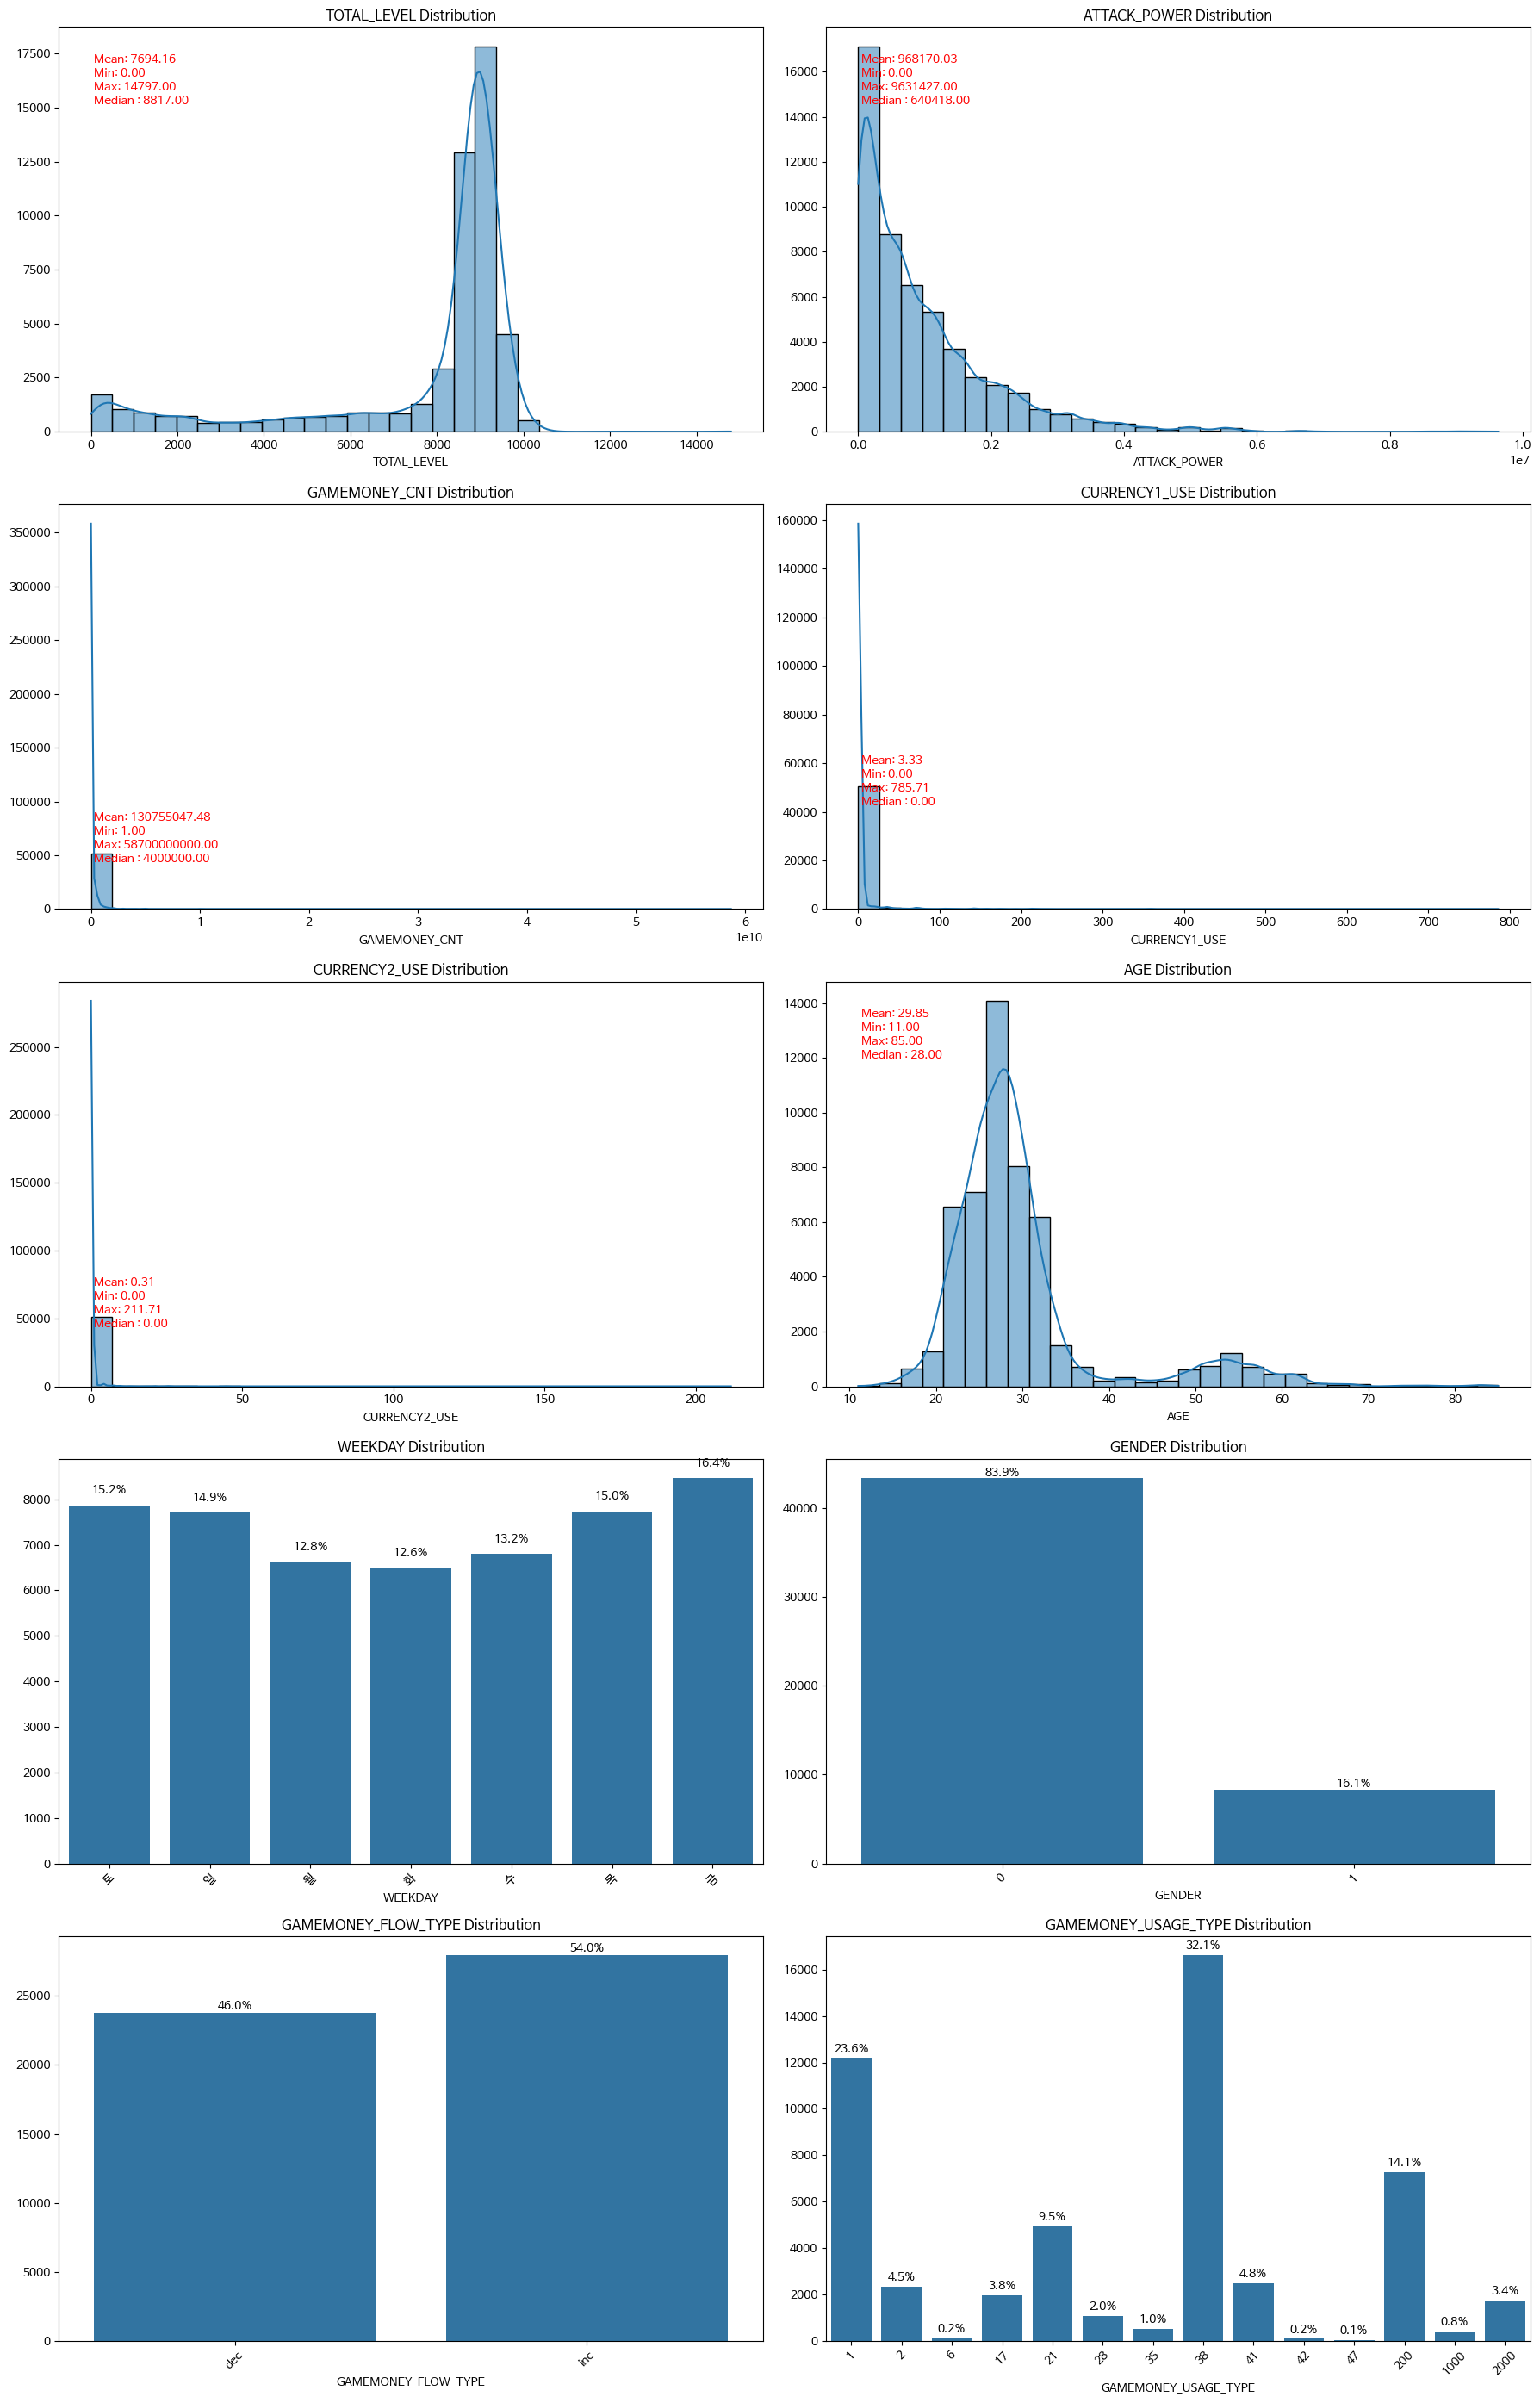

''

In [13]:
# 연속형 변수 리스트
num_cols = ['TOTAL_LEVEL', 'ATTACK_POWER', 'GAMEMONEY_CNT',
            'CURRENCY1_USE', 'CURRENCY2_USE','AGE']

# 범주형 변수 리스트
cat_cols = ['WEEKDAY', 'GENDER', 'GAMEMONEY_FLOW_TYPE', 'GAMEMONEY_USAGE_TYPE']

# 전체 그래프 그리기
fig, axes = plt.subplots(5, 2, figsize=(18, 28))
axes = axes.flatten()

# 1. 연속형 변수
for idx, col in enumerate(num_cols):
    ax = axes[idx]
    sns.histplot(user_money[col], bins=30, kde=True, ax=ax)
    custom_histogram(ax, user_money[col])
    ax.set_title(f'{col} Distribution')

# 2. 범주형 변수
for i, col in enumerate(cat_cols):
    ax = axes[len(num_cols) + i]
    cp = sns.countplot(data=user_money, x=col, ax=ax)
    custom_barplot(cp, user_money.shape[0])
    ax.set_title(f'{col} Distribution')
    ax.tick_params(axis='x', rotation=45)

# 여백 조정
plt.tight_layout()
plt.show()
;

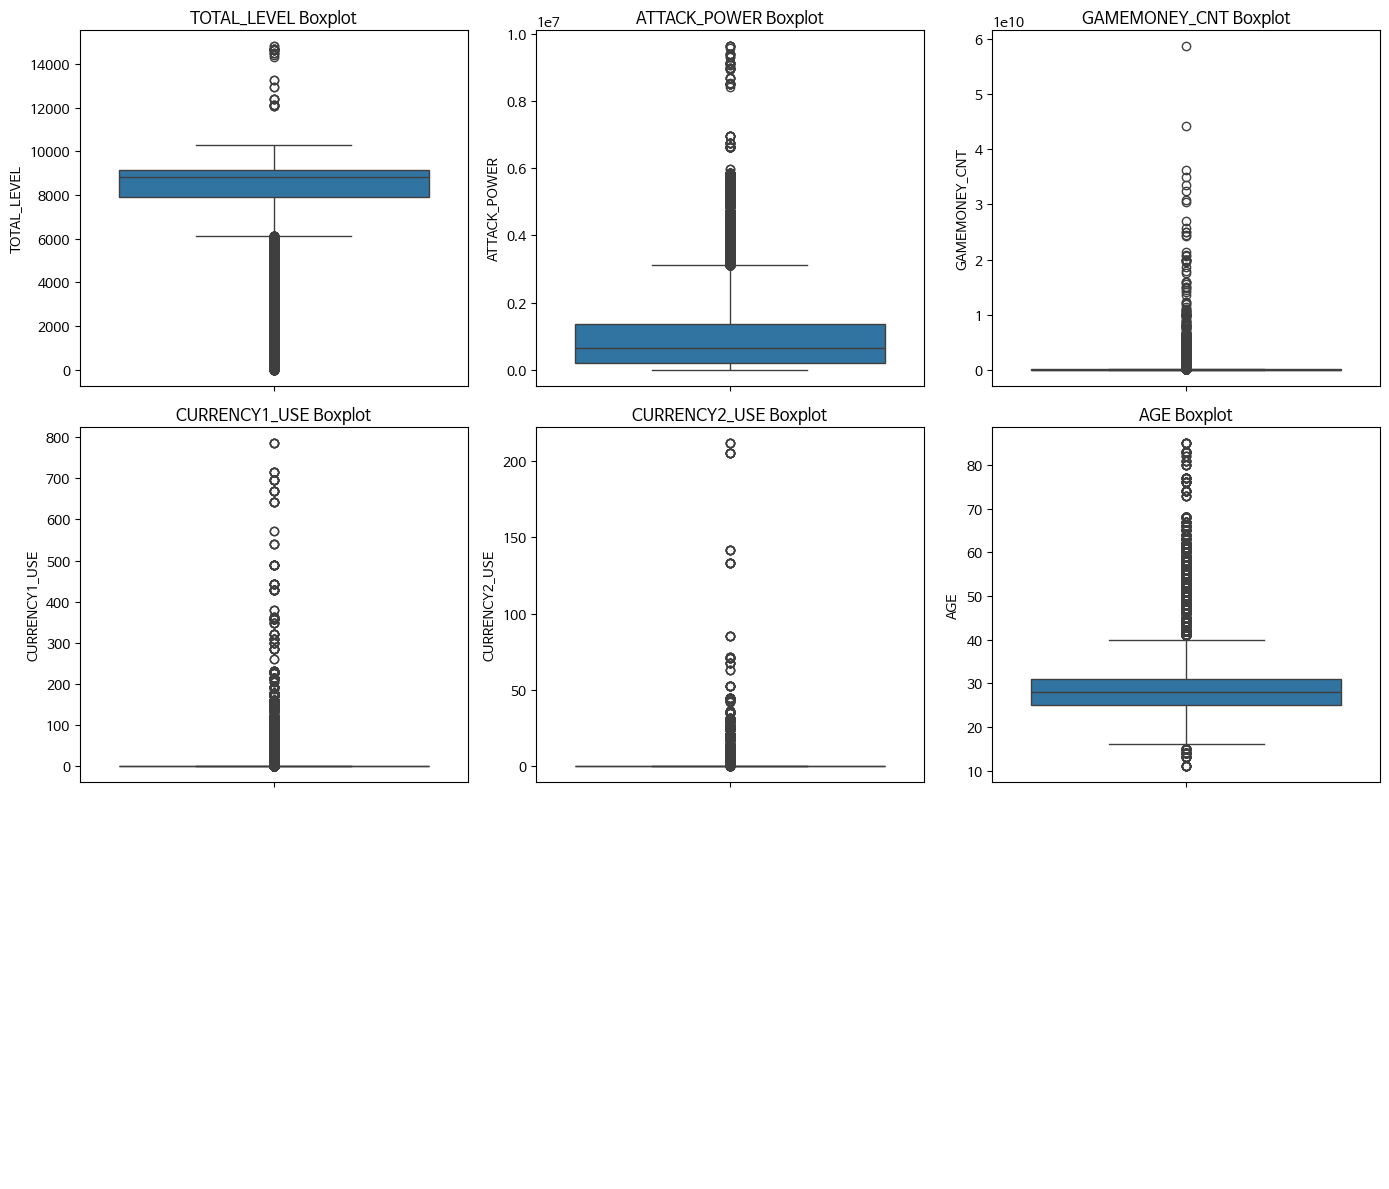

In [14]:
# 연속형 변수 리스트
num_cols = ['TOTAL_LEVEL','ATTACK_POWER','GAMEMONEY_CNT',
            'CURRENCY1_USE','CURRENCY2_USE','AGE']

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=user_money[col], ax=axes[i])
    axes[i].set_title(f'{col} Boxplot')

if len(num_cols) < len(axes):
    for j in range(len(num_cols), len(axes)):
        axes[j].axis('off')

plt.tight_layout()
plt.show()


In [15]:
# boxplot 이상치 개수 확인
con_var = ['TOTAL_LEVEL','ATTACK_POWER','GAMEMONEY_CNT','CURRENCY1_USE','CURRENCY2_USE','AGE']


for i in con_var :
    Q1 = user_money[i].quantile(0.25)
    Q3 = user_money[i].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = user_money[(user_money[i] < lower_bound) | (user_money[i] > upper_bound)]
    print(f"{i} 이상치 하한선 : {lower_bound}")
    print(f"{i} 이상치 상한선 : {upper_bound}")
    print(f"{i} 이상치 개수 : {len(outliers)}")

TOTAL_LEVEL 이상치 하한선 : 6098.0
TOTAL_LEVEL 이상치 상한선 : 10938.0
TOTAL_LEVEL 이상치 개수 : 9274
ATTACK_POWER 이상치 하한선 : -1538046.125
ATTACK_POWER 이상치 상한선 : 3110988.875
ATTACK_POWER 이상치 개수 : 2540
GAMEMONEY_CNT 이상치 하한선 : -35279248.625
GAMEMONEY_CNT 이상치 상한선 : 61313242.375
GAMEMONEY_CNT 이상치 개수 : 10198
CURRENCY1_USE 이상치 하한선 : 0.0
CURRENCY1_USE 이상치 상한선 : 0.0
CURRENCY1_USE 이상치 개수 : 3456
CURRENCY2_USE 이상치 하한선 : 0.0
CURRENCY2_USE 이상치 상한선 : 0.0
CURRENCY2_USE 이상치 개수 : 1334
AGE 이상치 하한선 : 16.0
AGE 이상치 상한선 : 40.0
AGE 이상치 개수 : 5340


In [16]:
# 상관계수 히트맵을 위한 인코딩 진행(gamemoney_flow,usage_type, weekday)

feature_summary(user_money)

,타입,고유값수,결측치수,중복치수,최솟값,최댓값,예시1,예시2
CREATED_DATE,datetime64[ns],7,0,256,2024-08-24 00:00:00,2024-08-30 00:00:00,2024-08-24 00:00:00,2024-08-24 00:00:00
USER_ID,object,2902,0,256,-,-,000378377E017CBF,000378377E017CBF
TOTAL_LEVEL,Int64,3055,2,256,0,14797,9183,9183
ATTACK_POWER,int64,9793,0,256,0,9631427,2389922,2389922
CURRENCY1_USE,float64,286,0,256,0.0,785.714286,0.0,0.0
CURRENCY2_USE,float64,118,0,256,0.0,211.714286,0.0,0.0
AGE,Int64,66,18,256,11,85,29,29
GENDER,int64,2,0,256,0,1,0,0
GAMEMONEY_FLOW_TYPE,object,2,0,256,-,-,dec,inc
GAMEMONEY_USAGE_TYPE,int64,14,0,256,1,2000,21,38


In [17]:
# gender, GAMEMONEY_FLOW_TYPE Label Encoding
user_money2 = user_money.copy()

# gender
user_money2['GENDER'] = user_money2['GENDER'].apply(lambda x: 1 if x == 1 else 0)

# gamemoney_flow_type
user_money2['GAMEMONEY_FLOW_TYPE'] = user_money2['GAMEMONEY_FLOW_TYPE'].apply(
                                    lambda x: 1 if x == 'inc' else 0
)

user_money2 = pd.get_dummies(user_money2, columns=['WEEKDAY'], dtype=int)

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


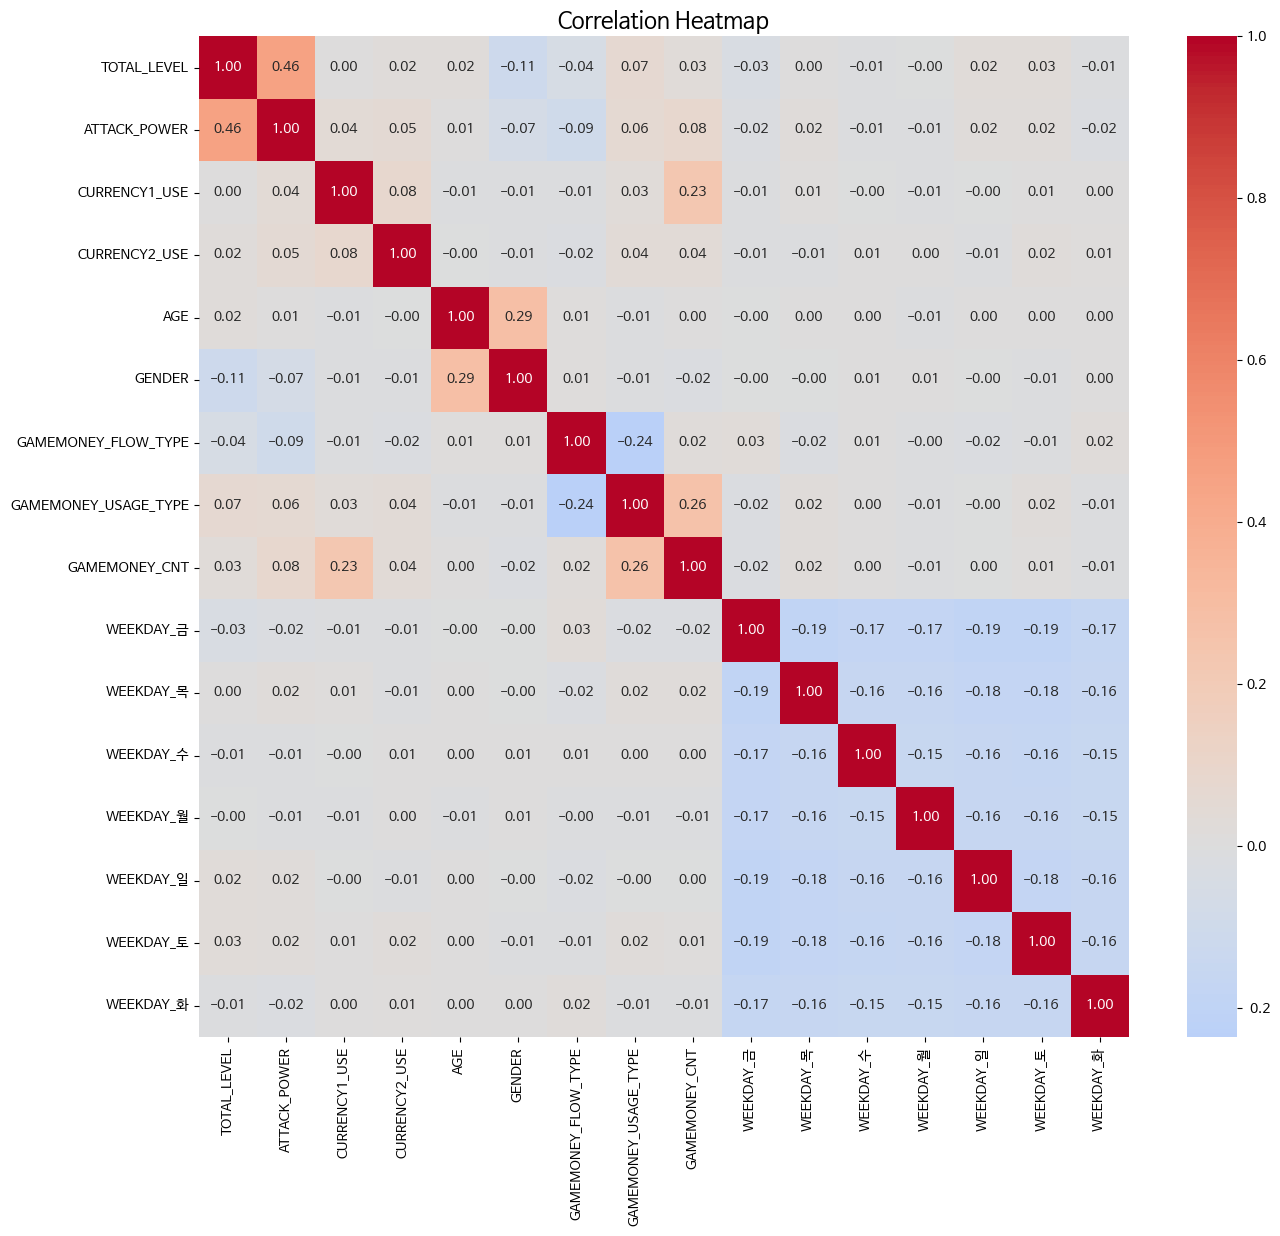

''

In [18]:
# 상관계수
corr = user_money2.drop(columns = ['USER_ID','CREATED_DATE']).corr()

# 4. 히트맵 시각화
plt.figure(figsize=(15, 13))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    center=0,
    cbar=True
)
plt.title('Correlation Heatmap', fontsize=16)

plt.show()
;

## 다변량 시각화(Tableau로 진행)

- 과제2에서의 핵심 변수는 강화
    - 강화는 즉 전투력과 직결되어있다.
    - 현재 데이터에서는 강화라고 직접적으로 표시된 변수가 없기에, 강화를 대변할 수 있는 전투력을 기준으로 다른 변수들과 시각화를 진행한다.
    - 즉, 전투력과 연관이 있는 변수들에 대해 미리 파악한다.
    - 단, 전투력은 복합적인 행동으로 인해 올라간다(레벨업, 강화, 장비 등)
        - 따라서 그래프의 형태가 명확히 나오거나 혹은 확실한 추세 파악은 어려운 것이 당연하다.
            - 이 부분은 가설 검정을 통해서 상관관계 그리고 추세선, 마지막 가설 검정을 통해 변수끼리의 관계를 명확히 한다

In [19]:
# 유저·날짜별로 정렬
user_money_sorted = user_money.sort_values(['USER_ID', 'CREATED_DATE'])

# GAMEMONEY_FLOW_TYPE + GAMEMONEY_CNT(inc -> + / dec -> -)
user_money_sorted['GAMEMONEY_CNT_FLOWTYPE'] = user_money_sorted.apply(
    lambda x: x['GAMEMONEY_CNT'] if x['GAMEMONEY_FLOW_TYPE'] == 'inc' else -x['GAMEMONEY_CNT']
    , axis=1
)

# 유저·날짜별 GAMEMONEY_CNT 순 변화량
flow_sum = user_money_sorted.groupby(['USER_ID','CREATED_DATE'])['GAMEMONEY_CNT_FLOWTYPE'].sum().reset_index()
flow_sum.rename(columns={'GAMEMONEY_CNT_FLOWTYPE':'GAMEMONEY_SUM'}, inplace=True)

# GAMEMONEY_USAGE_TYPE 금액 합 피벗 테이블
usage_sum = user_money_sorted.groupby(['USER_ID','CREATED_DATE','GAMEMONEY_USAGE_TYPE'])['GAMEMONEY_CNT'].sum().reset_index()
usage_pivot = usage_sum.pivot_table(
    index=['USER_ID','CREATED_DATE'],
    columns='GAMEMONEY_USAGE_TYPE',
    values='GAMEMONEY_CNT',
    fill_value=0
).reset_index()
usage_pivot.columns.name = None

# 나머지 컬럼 집계
other_col = user_money_sorted.groupby(['USER_ID','CREATED_DATE']).agg(
    TOTAL_LEVEL_FIRST=('TOTAL_LEVEL','first'),
    TOTAL_LEVEL_LAST=('TOTAL_LEVEL','last'),
    ATTACK_POWER_LAST=('ATTACK_POWER','last'),
    CURRENCY1_USE_SUM=('CURRENCY1_USE','sum'),
    CURRENCY2_USE_SUM=('CURRENCY2_USE','sum'),
    AGE_MODE=('AGE', lambda x: x.mode() if not x.mode().empty else np.nan),
    GENDER_MODE=('GENDER', lambda x: x.mode() if not x.mode().empty else np.nan),
    ).reset_index()

# 모든 결과 합치기
user_money_daily = other_col.merge(flow_sum, on=['USER_ID','CREATED_DATE'], how='left')\
                            .merge(usage_pivot, on=['USER_ID','CREATED_DATE'], how='left')\

# 결과 확인
user_money_daily.head(3)

,USER_ID,CREATED_DATE,TOTAL_LEVEL_FIRST,TOTAL_LEVEL_LAST,ATTACK_POWER_LAST,CURRENCY1_USE_SUM,CURRENCY2_USE_SUM,AGE_MODE,GENDER_MODE,GAMEMONEY_SUM,1,2,6,17,21,28,35,38,41,42,47,200,1000,2000
0,000378377E017CBF,2024-08-24,9183,9183,2389922,0.0,0.0,29,0,-23108849,14044928.0,0.0,0.0,0.0,2000000.0,0.0,0.0,4300088.0,0.0,0.0,0.0,11453865.0,0.0,0.0
1,000378377E017CBF,2024-08-25,9183,9183,2375927,0.0,0.0,29,0,-17912157,27.0,0.0,0.0,2948000.0,2000000.0,0.0,0.0,3176726.0,0.0,0.0,0.0,16140910.0,0.0,0.0
2,000378377E017CBF,2024-08-26,9183,9183,2067579,0.0,0.0,29,0,3524824,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3524824.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
user_money_daily.head(3)

,USER_ID,CREATED_DATE,TOTAL_LEVEL_FIRST,TOTAL_LEVEL_LAST,ATTACK_POWER_LAST,CURRENCY1_USE_SUM,CURRENCY2_USE_SUM,AGE_MODE,GENDER_MODE,GAMEMONEY_SUM,1,2,6,17,21,28,35,38,41,42,47,200,1000,2000
0,000378377E017CBF,2024-08-24,9183,9183,2389922,0.0,0.0,29,0,-23108849,14044928.0,0.0,0.0,0.0,2000000.0,0.0,0.0,4300088.0,0.0,0.0,0.0,11453865.0,0.0,0.0
1,000378377E017CBF,2024-08-25,9183,9183,2375927,0.0,0.0,29,0,-17912157,27.0,0.0,0.0,2948000.0,2000000.0,0.0,0.0,3176726.0,0.0,0.0,0.0,16140910.0,0.0,0.0
2,000378377E017CBF,2024-08-26,9183,9183,2067579,0.0,0.0,29,0,3524824,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3524824.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
user_money_daily[user_money_daily['ATTACK_POWER_LAST']==0]

,USER_ID,CREATED_DATE,TOTAL_LEVEL_FIRST,TOTAL_LEVEL_LAST,ATTACK_POWER_LAST,CURRENCY1_USE_SUM,CURRENCY2_USE_SUM,AGE_MODE,GENDER_MODE,GAMEMONEY_SUM,1,2,6,17,21,28,35,38,41,42,47,200,1000,2000
701,0AF85309EA03C969,2024-08-26,6601,6601,0,0.000000,0.0,24,0,-125000155,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.250002e+08,0.0,0.0
820,0C6E4D51E29A1035,2024-08-24,8337,8337,0,0.000000,0.0,30,0,-2151686,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.151686e+06,0.0,0.0
821,0C6E4D51E29A1035,2024-08-26,8337,8337,0,0.000000,0.0,30,0,-752060617,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.520606e+08,0.0,0.0
822,0C6E4D51E29A1035,2024-08-28,8337,8337,0,0.000000,0.0,30,0,-160000169,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.600002e+08,0.0,0.0
948,0E914733531683B1,2024-08-30,8545,8545,0,0.000000,0.0,29,0,15750160,35216200.0,0.0,0.0,0.0,2000000.0,0.0,0.0,4163275.0,0.0,0.0,0.0,1.362932e+07,0.0,0.0
1309,14467B0EAD916BAB,2024-08-30,4867,4867,0,0.000000,0.0,27,0,-1935211,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.935211e+06,0.0,0.0
1358,151EA285E096B166,2024-08-26,8888,8888,0,0.000000,0.0,23,0,3543000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3543000.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0
1426,160096E3DEC47502,2024-08-27,8895,8895,0,0.000000,0.0,25,0,1851,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1851.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0
1457,166199F1A6DEB644,2024-08-27,559,559,0,0.000000,0.0,21,0,-488889,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.888890e+05,0.0,0.0
1459,166199F1A6DEB644,2024-08-30,559,559,0,0.000000,0.0,21,0,-8000108,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.000108e+06,0.0,0.0


## 변수 간 관계 탐색 밑 가설 설정


In [22]:
# 분석 변수 선택
corr_vars = ['TOTAL_LEVEL', 'AGE', 'CURRENCY1_USE', 'CURRENCY2_USE', 'ATTACK_POWER']

# 상관계수
corr_matrix = user_money[corr_vars].corr()
print(corr_matrix['ATTACK_POWER'].sort_values(ascending=False))

ATTACK_POWER     1.000000
TOTAL_LEVEL      0.458625
CURRENCY2_USE    0.052816
CURRENCY1_USE    0.039370
AGE              0.007500
Name: ATTACK_POWER, dtype: float64


### TOTAL_LEVEL- ATTACK_POWER

In [23]:
# 1. 상위/하위 25% 그룹 분할을 위한 데이터 준비

variance = 'TOTAL_LEVEL'
attack = 'ATTACK_POWER'

# 전투력 0 데이터 제외 (분석에 의미 없는 데이터)
df_nonzero_attack = user_money[user_money[attack] > 0]

# 하위/상위 25% 분위수 계산
lower_quantile = df_nonzero_attack[variance].quantile(0.25)
upper_quantile = df_nonzero_attack[variance].quantile(0.75)

# 그룹 분할
low_attack_group = df_nonzero_attack[df_nonzero_attack[variance] <= lower_quantile][attack]
high_attack_group = df_nonzero_attack[df_nonzero_attack[variance] >= upper_quantile][attack]

print(f'분석 대상 그룹 크기 : 하위 그룹 = {len(low_attack_group)}, 상위 그룹 = {len(high_attack_group)}\n')

분석 대상 그룹 크기 : 하위 그룹 = 12897, 상위 그룹 = 12925



In [24]:
# 2. T-test 가정 검토

# 2-1. 정규성 검정(Shapiro-Wilk)
sample_limit = 5000
random_seed = 42

def shapiro_test(group, name) :
    if len(group) > sample_limit :
        group_sampled = group.sample(n=sample_limit, random_state=random_seed)
    else :
        group_sampled = group

    statistics, p_value = stats.shapiro(group_sampled)

    if p_value >= 0.05 :
        result = '정규분포 만족 -> t-test 가능'
    else :
        if len(group) >= 200 :
            result = (f'정규분포 충족하지 않지만 표본 개수({len(group)}) 충분 -> t-test 가능')
        else :
            result = '정규분포 충족하지 않으며 표본 개수 부족 -> t-test 진행 불가'

    print(f'{name} → Statistic={statistics:.4f}, p-value={p_value:.4f} → {result}')
    return result

# 하위/상위 그룹 정규성 검정
shapiro_low = shapiro_test(low_attack_group, '하위 그룹')
shapiro_high = shapiro_test(high_attack_group, '상위 그룹')

하위 그룹 → Statistic=0.3840, p-value=0.0000 → 정규분포 충족하지 않지만 표본 개수(12897) 충분 -> t-test 가능
상위 그룹 → Statistic=0.9159, p-value=0.0000 → 정규분포 충족하지 않지만 표본 개수(12925) 충분 -> t-test 가능


In [25]:
# 3. 등분산 가정 검정(Levene's test)
levene_stat, levene_p = stats.levene(low_attack_group, high_attack_group)

if levene_p >= 0.05:
    equal_variance = True
    result_text = "등분산 가정 만족 → 일반 t-test 가능 or Welch t-test 사용 가능"
else:
    equal_variance = False
    result_text = "등분산 가정 불만족 → Welch t-test 사용 권장"

print(f"Levene 검정\nStatistic={levene_stat:.4f}, p-value={levene_p:.4f} → {result_text}")

Levene 검정
Statistic=10711.5818, p-value=0.0000 → 등분산 가정 불만족 → Welch t-test 사용 권장


In [26]:
# 4. T-test 수행 및 효과 크기 개선

# 4-1. t-test 수행
t_stat, t_p_value = stats.ttest_ind(low_attack_group, high_attack_group, equal_var=equal_variance)
print(f"T-test 결과\nT= {t_stat:.4f}, p-value= {t_p_value:.4f}")

if t_p_value < 0.05:
    print("-> 귀무가설 기각: 상/하위 그룹 평균 차이 통계적으로 유의미\n")
else:
    print("-> 귀무가설 채택: 상/하위 그룹 평균 차이 통계적으로 유의미하지 않음\n")

# 5. 실제 평균 확인
mean_low, mean_high = low_attack_group.mean(), high_attack_group.mean()
print(f"하위 그룹 평균 {attack}: {mean_low:.2f}, 상위 그룹 평균 {attack}: {mean_high:.2f}\n")

# 6. 효과 크기(Cohen's d) 확인
# Cohen's d 계산
std_low = np.std(low_attack_group, ddof=1)
std_high = np.std(high_attack_group, ddof=1)
std_pooled = np.sqrt((std_low**2 + std_high**2) / 2)

cohen_d = (mean_high - mean_low) / std_pooled
print(f"Cohen's d: {cohen_d:.3f}")

# 효과 크기 해석 (절댓값 기준)
if abs(cohen_d) < 0.2:
    print("일반적으로 매우 작은 효과")
elif abs(cohen_d) < 0.5:
    print("일반적으로 작은 효과")
elif abs(cohen_d) < 0.8:
    print("일반적으로 중간 효과")
else:
    print("일반적으로 큰 효과")

T-test 결과
T= -147.0106, p-value= 0.0000
-> 귀무가설 기각: 상/하위 그룹 평균 차이 통계적으로 유의미

하위 그룹 평균 ATTACK_POWER: 153420.85, 상위 그룹 평균 ATTACK_POWER: 1763606.82

Cohen's d: 1.829
일반적으로 큰 효과


### GAMEMONEY_CNT-ATTACK_POWER

In [27]:
variance = 'GAMEMONEY_CNT'
attack = 'ATTACK_POWER'

# 1. 데이터 준비 및 상위/하위 25% 그룹 분할

## 1-1. 전투력 0 데이터 제외 -> 전투력 0은 도움이 여기서 도움이 되지 않는 데이터
df_nonzero = user_money[user_money[attack] > 0]

## 1-2. 상위/하위 25% 분위수 계산
lower_var = df_nonzero[variance].quantile(0.25)
upper_var = df_nonzero[variance].quantile(0.75)

## 1-3. 그룹 분할
low_gamecnt_group = df_nonzero[df_nonzero[variance] <= lower_var][attack]
high_gamecnt_group = df_nonzero[df_nonzero[variance] >= upper_var][attack]


print(f'분석 대상 그룹 크기 : 하위 그룹 = {len(low_gamecnt_group)}, 상위 그룹 = {len(high_gamecnt_group)}\n')

분석 대상 그룹 크기 : 하위 그룹 = 12896, 상위 그룹 = 12896



In [28]:
# 2. T-test 가정 검토

# 2-1. 정규성 검정(Shapiro-Wilk)
sample_limit = 5000
random_seed = 42



# 하위/상위 그룹 정규성 검정
shapiro_low = shapiro_test(low_gamecnt_group, '하위 그룹')
shapiro_high = shapiro_test(high_gamecnt_group, '상위 그룹')

하위 그룹 → Statistic=0.7122, p-value=0.0000 → 정규분포 충족하지 않지만 표본 개수(12896) 충분 -> t-test 가능
상위 그룹 → Statistic=0.8408, p-value=0.0000 → 정규분포 충족하지 않지만 표본 개수(12896) 충분 -> t-test 가능


In [29]:
# 3. 등분산 가정 검정(Levene's test)
levene_stat, levene_p = stats.levene(low_gamecnt_group, high_gamecnt_group)

if levene_p >= 0.05:
    equal_variance = True
    result_text = "등분산 가정 만족 → 일반 t-test 가능 or Welch t-test 사용 가능"
else:
    equal_variance = False
    result_text = "등분산 가정 불만족 → Welch t-test 사용 권장"

print(f"Levene 검정\nStatistic={levene_stat:.4f}, p-value={levene_p:.4f} → {result_text}")

Levene 검정
Statistic=817.8177, p-value=0.0000 → 등분산 가정 불만족 → Welch t-test 사용 권장


In [30]:
# 4. T-test 수행 및 효과 크기 개선

# 4-1. t-test 수행
t_stat, t_p_value = stats.ttest_ind(low_gamecnt_group, high_gamecnt_group, equal_var=equal_variance)
print(f"T-test 결과\nT= {t_stat:.4f}, p-value= {t_p_value:.4f}")

if t_p_value < 0.05:
    print("-> 귀무가설 기각: 상/하위 그룹 평균 차이 통계적으로 유의미\n")
else:
    print("-> 귀무가설 채택: 상/하위 그룹 평균 차이 통계적으로 유의미하지 않음\n")

# 5. 실제 평균 확인
mean_low, mean_high = low_gamecnt_group.mean(), high_gamecnt_group.mean()
print(f"하위 그룹 평균 {attack}: {mean_low:.2f}, 상위 그룹 평균 {attack}: {mean_high:.2f}\n")

# 6. 효과 크기(Cohen's d) 확인
# Cohen's d 계산
std_low = np.std(low_gamecnt_group, ddof=1)
std_high = np.std(high_gamecnt_group, ddof=1)
std_pooled = np.sqrt((std_low**2 + std_high**2) / 2)

cohen_d = (mean_high - mean_low) / std_pooled
print(f"Cohen's d: {cohen_d:.3f}")

# 효과 크기 해석 (절댓값 기준)
if abs(cohen_d) < 0.2:
    print("일반적으로 매우 작은 효과")
elif abs(cohen_d) < 0.5:
    print("일반적으로 작은 효과")
elif abs(cohen_d) < 0.8:
    print("일반적으로 중간 효과")
else:
    print("일반적으로 큰 효과")

T-test 결과
T= -46.9466, p-value= 0.0000
-> 귀무가설 기각: 상/하위 그룹 평균 차이 통계적으로 유의미

하위 그룹 평균 ATTACK_POWER: 627428.93, 상위 그룹 평균 ATTACK_POWER: 1221639.46

Cohen's d: 0.585
일반적으로 중간 효과


### GAMEMONEY_USAGE_TYPE - ATTACK_POWER

In [31]:
# 0. 환경 변수 정의
variance = 'GAMEMONEY_USAGE_TYPE'
attack = 'ATTACK_POWER'
sample_limit = 5000
random_seed = 42
problem_group = []
normal_count = 0
robust_ok_count = 0


# 1. 데이터 준비
df_nonzero = user_money[user_money[attack] > 0]

grouped_data = df_nonzero.groupby(variance)[attack]
groups_list = [group_data for name, group_data in grouped_data]
group_names = [name for name, group_data in grouped_data]

print('1. 데이터 준비 및 그룹 분할\n')
print(f"총 분석 대상 그룹 수: {len(group_names)}개\n")

1. 데이터 준비 및 그룹 분할

총 분석 대상 그룹 수: 14개



In [32]:
# 2. 정규성 검정
def shapiro_test_anova(groups_list, group_names, sample_limit, random_seed):
    results = []
    problem_group = []
    normal_count = 0
    robust_groups_count = 0

    for i, group_data in enumerate(groups_list):
        group_name = group_names[i]
        original_n = len(group_data)

        # 표본 제한
        if original_n > sample_limit:
            group_data = group_data.sample(n=sample_limit, random_state=random_seed)

        # 표본 너무 작으면 검정 불가
        if len(group_data) < 3:
            problem_group.append(f"[{group_name}] N={original_n} → 너무 작음, 검정 불가")
            continue

        statistics, p_value = stats.shapiro(group_data)

        if p_value >= 0.05:
            status = '정규분포 만족 → t-test 가능'
            normal_count += 1
        else:
            if original_n >= 200:
                status = f'정규분포 위반이지만 N={original_n} 충분 → t-test 가능'
                robust_groups_count += 1
            else:
                status = f'정규성 위반 + 표본 부족 (p={p_value:.4f})'
                problem_group.append(f"[{group_name}] N={original_n} → 정규성 위반")

        results.append({'그룹': group_name, 'N': original_n, 'Statistic': statistics, 'p-value': p_value, '상태': status})

    # 출력
    for r in results:
        print(f"{r['그룹']}: N={r['N']}, Statistic={r['Statistic']:.4f}, p-value={r['p-value']:.4f} → {r['상태']}")

    print('\n정규성 검정 요약:')
    print(f" - 정규성 만족: {normal_count}개 그룹")
    print(f" - 정규성 위반, N 충분: {robust_groups_count}개 그룹")
    if problem_group:
        print(" - 주의 필요 그룹:")
        for msg in problem_group:
            print(f"   * {msg}")

    return results, problem_group

results, problem_group = shapiro_test_anova(
    groups_list=groups_list,
    group_names=group_names,
    sample_limit=sample_limit,
    random_seed=random_seed)

1: N=12172, Statistic=0.8041, p-value=0.0000 → 정규분포 위반이지만 N=12172 충분 → t-test 가능
2: N=2322, Statistic=0.7559, p-value=0.0000 → 정규분포 위반이지만 N=2322 충분 → t-test 가능
6: N=105, Statistic=0.7825, p-value=0.0000 → 정규성 위반 + 표본 부족 (p=0.0000)
17: N=1944, Statistic=0.7522, p-value=0.0000 → 정규분포 위반이지만 N=1944 충분 → t-test 가능
21: N=4915, Statistic=0.8531, p-value=0.0000 → 정규분포 위반이지만 N=4915 충분 → t-test 가능
28: N=1055, Statistic=0.6489, p-value=0.0000 → 정규분포 위반이지만 N=1055 충분 → t-test 가능
35: N=498, Statistic=0.7817, p-value=0.0000 → 정규분포 위반이지만 N=498 충분 → t-test 가능
38: N=16579, Statistic=0.7849, p-value=0.0000 → 정규분포 위반이지만 N=16579 충분 → t-test 가능
41: N=2487, Statistic=0.8386, p-value=0.0000 → 정규분포 위반이지만 N=2487 충분 → t-test 가능
42: N=88, Statistic=0.8732, p-value=0.0000 → 정규성 위반 + 표본 부족 (p=0.0000)
47: N=27, Statistic=0.9555, p-value=0.2910 → 정규분포 만족 → t-test 가능
200: N=7244, Statistic=0.8350, p-value=0.0000 → 정규분포 위반이지만 N=7244 충분 → t-test 가능
1000: N=414, Statistic=0.7974, p-value=0.0000 → 정규분포 위반이지만 N=414 충분 → t-

In [33]:
# 3. 등분산 가정 검정(Levene's test)
levene_stat, levene_p = stats.levene(*groups_list)
print(f"Statistic={levene_stat:.4f}, p-value={levene_p:.4f}")

equal_variance = True
if levene_p < 0.05 :
    print(" -> 귀무가설 기각 : 등분산 위반 -> Welch ANOVA 또는 비모수 검정 고려 권장")
    equal_variance=False
else :
    print(" -> 귀무가설 채택 : 등분산 가정 충족")
    print(" -> 표준 one-way ANOVA 사용 가능"'\n')


Statistic=27.6522, p-value=0.0000
 -> 귀무가설 기각 : 등분산 위반 -> Welch ANOVA 또는 비모수 검정 고려 권장


In [34]:
# 4. ANOVA 수행 및 결과 해석
model = ols(f'{attack} ~ C({variance})', data=df_nonzero).fit()

# robust 옵션: 등분산 위반
anova_table = sm.stats.anova_lm(model, typ=2, robust='hc3')
print("4. ANOVA 결과 (Welch ANOVA, 등분산 위반)")
print(anova_table)

# 5. 사후 검정 (Tukey HSD)
tukey = pairwise_tukeyhsd(endog=df_nonzero[attack], groups=df_nonzero[variance], alpha=0.05)
print("사후 검정 결과")
print(tukey)

# 6. 실제 평균 확인

# 그룹별 평균 계산
group_means = df_nonzero.groupby(variance)[attack].mean().reset_index()
group_means.rename(columns={attack: 'Mean_Attack'}, inplace=True)

print(group_means)



4. ANOVA 결과 (Welch ANOVA, 등분산 위반)
                               sum_sq       df          F         PR(>F)
C(GAMEMONEY_USAGE_TYPE)  1.061732e+15     13.0  75.921625  1.043766e-200
Residual                 5.547467e+16  51569.0        NaN            NaN
사후 검정 결과
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
group1 group2    meandiff   p-adj      lower         upper     reject
---------------------------------------------------------------------
     1      2  -160081.2929    0.0  -238852.8784   -81309.7074   True
     1      6   -97282.8963 0.9996  -438207.2646    243641.472  False
     1     17   -184836.184    0.0  -269796.1364   -99876.2315   True
     1     21   205477.5657    0.0   146691.0507   264264.0807   True
     1     28  -289821.8579    0.0   -401459.592  -178184.1238   True
     1     35     6759.3148    1.0  -152271.1039   165789.7334  False
     1     38  -102824.0211    0.0  -144343.6897   -61304.3526   True
     1     41   233405.5078    0.0   1

In [35]:
# 7. 효과 크기(Eta-squared)
all_attack = df_nonzero[attack]
ss_total = np.sum((all_attack - all_attack.mean())**2)
ss_between = 0
for data in groups_list :
    ss_between += len(data) * (data.mean() - all_attack.mean())**2
eta_squared = ss_between / ss_total

print(f"Eta-squared: {eta_squared:.3f}")

## 7-1. 효과 크기 해석
if eta_squared < 0.01 :
    print("일반적으로 매우 작은 효과")
elif eta_squared < 0.06 :
    print("일반적으로 작은 효과 (Small effect)")
elif eta_squared < 0.14 :
    print("일반적으로 중간 효과 (Medium effect)")
else :
    print("일반적으로 큰 효과 (Large effect)")

Eta-squared: 0.022
일반적으로 작은 효과 (Small effect)


### CURRENCY2_USE - ATTACK_POWER

In [36]:
# 1. 그룹 분할을 위한 데이터 준비

variance = 'CURRENCY2_USE'
attack = 'ATTACK_POWER'

lower_var = df_nonzero[variance] == 0
upper_var = df_nonzero[variance] != 0

low_cur2_group = df_nonzero[lower_var][attack]
high_cur2_group = df_nonzero[upper_var][attack]


print(f'분석 대상 그룹 크기 : 하위 그룹 = {len(low_cur2_group)}, 상위 그룹 = {len(high_cur2_group)}\n')

분석 대상 그룹 크기 : 하위 그룹 = 50249, 상위 그룹 = 1334



In [37]:
# 2. T-test 가정 검토

# 2-1. 정규성 검정(Shapiro-Wilk)
sample_limit = 5000
random_seed = 42

def shapiro_test(group, name) :
    if len(group) > sample_limit :
        group_sampled = group.sample(n=sample_limit, random_state=random_seed)
    else :
        group_sampled = group

    statistics, p_value = stats.shapiro(group_sampled)

    if p_value >= 0.05 :
        result = '정규분포 만족 -> t-test 가능'
    else :
        if len(group) >= 200 :
            result = (f'정규분포 충족하지 않지만 표본 개수({len(group)}) 충분 -> t-test 가능')
        else :
            result = '정규분포 충족하지 않으며 표본 개수 부족 -> t-test 진행 불가'

    print(f'{name} → Statistic={statistics:.4f}, p-value={p_value:.4f} → {result}')
    return result

# 하위/상위 그룹 정규성 검정
shapiro_low = shapiro_test(low_cur2_group, '하위 그룹')
shapiro_high = shapiro_test(high_cur2_group, '상위 그룹')

하위 그룹 → Statistic=0.7940, p-value=0.0000 → 정규분포 충족하지 않지만 표본 개수(50249) 충분 -> t-test 가능
상위 그룹 → Statistic=0.8593, p-value=0.0000 → 정규분포 충족하지 않지만 표본 개수(1334) 충분 -> t-test 가능


In [38]:
# 3. 등분산 가정 검정(Levene's test)
levene_stat, levene_p = stats.levene(low_cur2_group, high_cur2_group)

if levene_p >= 0.05:
    equal_variance = True
    result_text = "등분산 가정 만족 → 일반 t-test 가능 or Welch t-test 사용 가능"
else:
    equal_variance = False
    result_text = "등분산 가정 불만족 → Welch t-test 사용 권장"

print(f"Levene 검정\nStatistic={levene_stat:.4f}, p-value={levene_p:.4f} → {result_text}")

Levene 검정
Statistic=110.8580, p-value=0.0000 → 등분산 가정 불만족 → Welch t-test 사용 권장


In [39]:
# 4. T-test 수행 및 효과 크기 개선

# 4-1. t-test 수행
t_stat, t_p_value = stats.ttest_ind(low_cur2_group, high_cur2_group, equal_var=equal_variance)
print(f"T-test 결과\nT= {t_stat:.4f}, p-value= {t_p_value:.4f}")

if t_p_value < 0.05:
    print("-> 귀무가설 기각: 상/하위 그룹 평균 차이 통계적으로 유의미\n")
else:
    print("-> 귀무가설 채택: 상/하위 그룹 평균 차이 통계적으로 유의미하지 않음\n")

# 5. 실제 평균 확인
mean_low, mean_high = low_cur2_group.mean(), high_cur2_group.mean()
print(f"하위 그룹 평균 {attack}: {mean_low:.2f}, 상위 그룹 평균 {attack}: {mean_high:.2f}\n")

# 6. 효과 크기(Cohen's d) 확인
# Cohen's d 계산
std_low = np.std(low_cur2_group, ddof=1)
std_high = np.std(high_cur2_group, ddof=1)
std_pooled = np.sqrt((std_low**2 + std_high**2) / 2)

cohen_d = (mean_high - mean_low) / std_pooled
print(f"Cohen's d: {cohen_d:.3f}")

# 효과 크기 해석 (절댓값 기준)
if abs(cohen_d) < 0.2:
    print("일반적으로 매우 작은 효과")
elif abs(cohen_d) < 0.5:
    print("일반적으로 작은 효과")
elif abs(cohen_d) < 0.8:
    print("일반적으로 중간 효과")
else:
    print("일반적으로 큰 효과")

T-test 결과
T= -10.7935, p-value= 0.0000
-> 귀무가설 기각: 상/하위 그룹 평균 차이 통계적으로 유의미

하위 그룹 평균 ATTACK_POWER: 959953.27, 상위 그룹 평균 ATTACK_POWER: 1348077.37

Cohen's d: 0.329
일반적으로 작은 효과


### CURRENCY1_USE - ATTACK_POWER

In [40]:
# 1. 그룹 분할을 위한 데이터 준비

variance = 'CURRENCY1_USE'
attack = 'ATTACK_POWER'

lower_var = df_nonzero[variance] == 0
upper_var = df_nonzero[variance] != 0

low_cur2_group = df_nonzero[lower_var][attack]
high_cur2_group = df_nonzero[upper_var][attack]


print(f'분석 대상 그룹 크기 : 하위 그룹 = {len(low_cur2_group)}, 상위 그룹 = {len(high_cur2_group)}\n')

분석 대상 그룹 크기 : 하위 그룹 = 48130, 상위 그룹 = 3453



In [41]:
# 2. T-test 가정 검토

# 2-1. 정규성 검정(Shapiro-Wilk)
sample_limit = 5000
random_seed = 42

def shapiro_test(group, name) :
    if len(group) > sample_limit :
        group_sampled = group.sample(n=sample_limit, random_state=random_seed)
    else :
        group_sampled = group

    statistics, p_value = stats.shapiro(group_sampled)

    if p_value >= 0.05 :
        result = '정규분포 만족 -> t-test 가능'
    else :
        if len(group) >= 200 :
            result = (f'정규분포 충족하지 않지만 표본 개수({len(group)}) 충분 -> t-test 가능')
        else :
            result = '정규분포 충족하지 않으며 표본 개수 부족 -> t-test 진행 불가'

    print(f'{name} → Statistic={statistics:.4f}, p-value={p_value:.4f} → {result}')
    return result

# 하위/상위 그룹 정규성 검정
shapiro_low = shapiro_test(low_cur2_group, '하위 그룹')
shapiro_high = shapiro_test(high_cur2_group, '상위 그룹')

하위 그룹 → Statistic=0.8140, p-value=0.0000 → 정규분포 충족하지 않지만 표본 개수(48130) 충분 -> t-test 가능
상위 그룹 → Statistic=0.7949, p-value=0.0000 → 정규분포 충족하지 않지만 표본 개수(3453) 충분 -> t-test 가능


In [42]:
# 3. 등분산 가정 검정(Levene's test)
levene_stat, levene_p = stats.levene(low_cur2_group, high_cur2_group)

if levene_p >= 0.05:
    equal_variance = True
    result_text = "등분산 가정 만족 → 일반 t-test 가능 or Welch t-test 사용 가능"
else:
    equal_variance = False
    result_text = "등분산 가정 불만족 → Welch t-test 사용 권장"

print(f"Levene 검정\nStatistic={levene_stat:.4f}, p-value={levene_p:.4f} → {result_text}")

Levene 검정
Statistic=22.5619, p-value=0.0000 → 등분산 가정 불만족 → Welch t-test 사용 권장


In [43]:
# 4. T-test 수행 및 효과 크기 개선

# 4-1. t-test 수행
t_stat, t_p_value = stats.ttest_ind(low_cur2_group, high_cur2_group, equal_var=equal_variance)
print(f"T-test 결과\nT= {t_stat:.4f}, p-value= {t_p_value:.4f}")

if t_p_value < 0.05:
    print("-> 귀무가설 기각: 상/하위 그룹 평균 차이 통계적으로 유의미\n")
else:
    print("-> 귀무가설 채택: 상/하위 그룹 평균 차이 통계적으로 유의미하지 않음\n")

# 5. 실제 평균 확인
mean_low, mean_high = low_cur2_group.mean(), high_cur2_group.mean()
print(f"하위 그룹 평균 {attack}: {mean_low:.2f}, 상위 그룹 평균 {attack}: {mean_high:.2f}\n")

# 6. 효과 크기(Cohen's d) 확인
# Cohen's d 계산
std_low = np.std(low_cur2_group, ddof=1)
std_high = np.std(high_cur2_group, ddof=1)
std_pooled = np.sqrt((std_low**2 + std_high**2) / 2)

cohen_d = (mean_high - mean_low) / std_pooled
print(f"Cohen's d: {cohen_d:.3f}")

# 효과 크기 해석 (절댓값 기준)
if abs(cohen_d) < 0.2:
    print("일반적으로 매우 작은 효과")
elif abs(cohen_d) < 0.5:
    print("일반적으로 작은 효과")
elif abs(cohen_d) < 0.8:
    print("일반적으로 중간 효과")
else:
    print("일반적으로 큰 효과")

T-test 결과
T= -1.9432, p-value= 0.0521
-> 귀무가설 채택: 상/하위 그룹 평균 차이 통계적으로 유의미하지 않음

하위 그룹 평균 ATTACK_POWER: 967361.44, 상위 그룹 평균 ATTACK_POWER: 1006637.93

Cohen's d: 0.036
일반적으로 매우 작은 효과


### AGE - ATTACK_POWER

In [44]:
# 0. 환경 변수 정의
variance = 'AGE'
attack = 'ATTACK_POWER'
sample_limit = 5000
random_seed = 42

# 1. 데이터 준비
df_nonzero = user_money[user_money[attack] > 0].dropna(subset=[variance])

# 1-1. 그룹
lower_var = df_nonzero[variance].quantile(0.25)
upper_var = df_nonzero[variance].quantile(0.75)

df_nonzero['AGE_GROUP'] = 'Mid'
df_nonzero.loc[df_nonzero[variance] <= lower_var, 'AGE_GROUP'] = 'Low'
df_nonzero.loc[df_nonzero[variance] >= upper_var, 'AGE_GROUP'] = 'High'

low_group = df_nonzero[df_nonzero['AGE_GROUP'] == 'Low'][attack]
mid_group = df_nonzero[df_nonzero['AGE_GROUP'] == 'Mid'][attack]
high_group = df_nonzero[df_nonzero['AGE_GROUP'] == 'High'][attack]

groups_list = [low_group, mid_group, high_group]
group_names = ['Low', 'Mid', 'High']

print(f"총 분석 대상 그룹 수: {len(group_names)}개\n")

총 분석 대상 그룹 수: 3개



In [45]:
# 정규성 검정
for name, group in zip(group_names, groups_list):
    data = group.sample(n=sample_limit, random_state=random_seed) if len(group) > sample_limit else group
    stat, p_value = stats.shapiro(data)
    print(f"{name} 그룹: N={len(group)}, Statistic={stat:.4f}, p-value={p_value:.4f}", end=' ')
    if p_value < 0.05:
        if len(group) >= 200:
            print("→ 정규분포 위반, 표본 충분 → ANOVA 진행 가능")
        else:
            print("→ 정규분포 위반, 표본 부족 → ANOVA 사용 불가")
    else:
        print("→ 정규분포 만족 → ANOVA 진행 가능")

Low 그룹: N=15680, Statistic=0.8208, p-value=0.0000 → 정규분포 위반, 표본 충분 → ANOVA 진행 가능
Mid 그룹: N=22086, Statistic=0.8337, p-value=0.0000 → 정규분포 위반, 표본 충분 → ANOVA 진행 가능
High 그룹: N=13799, Statistic=0.7847, p-value=0.0000 → 정규분포 위반, 표본 충분 → ANOVA 진행 가능


In [46]:
# 3. 등분산 가정 검정(Levene's test)
levene_stat, levene_p = stats.levene(*groups_list)
print('3. 등분산 검정 (Levene\'s test)')
print(f"Statistic={levene_stat:.4f}, p-value={levene_p:.4f}", end=' ')
equal_variance = True
if levene_p < 0.05:
    print(" -> 귀무가설 기각 : 등분산 위반 -> Welch ANOVA 또는 비모수 검정 고려 권장")
    equal_variance=False
else :
    print(" -> 귀무가설 채택 : 등분산 가정 충족")
    print(" -> 표준 one-way ANOVA 사용 가능"'\n')


3. 등분산 검정 (Levene's test)
Statistic=380.9939, p-value=0.0000  -> 귀무가설 기각 : 등분산 위반 -> Welch ANOVA 또는 비모수 검정 고려 권장


In [47]:
# 4. ANOVA 수행 및 결과 해석
model = ols(f'{attack} ~ C(AGE_GROUP)', data=df_nonzero).fit()

# robust 옵션: 등분산 위반
anova_table = sm.stats.anova_lm(model, typ=2, robust='hc3')
print("4. ANOVA 결과 (Welch ANOVA, 등분산 위반)")
print(anova_table)

# 5. 사후 검정 (Tukey HSD)
tukey = pairwise_tukeyhsd(endog=df_nonzero[attack], groups=df_nonzero['AGE_GROUP'], alpha=0.05)
print("사후 검정 결과")
print(tukey)

# 6. 실제 평균 확인
group_means = df_nonzero.groupby('AGE_GROUP')[attack].mean()
print(group_means)

4. ANOVA 결과 (Welch ANOVA, 등분산 위반)
                    sum_sq       df           F         PR(>F)
C(AGE_GROUP)  1.308107e+15      2.0  607.188232  2.284934e-261
Residual      5.554177e+16  51562.0         NaN            NaN
사후 검정 결과
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
group1 group2   meandiff   p-adj    lower        upper     reject
-----------------------------------------------------------------
  High    Low -165595.2013   0.0 -193988.7189 -137201.6836   True
  High    Mid  183428.2099   0.0  157032.4727  209823.9472   True
   Low    Mid  349023.4112   0.0  323620.7864   374426.036   True
-----------------------------------------------------------------
AGE_GROUP
High    9.418595e+05
Low     7.762643e+05
Mid     1.125288e+06
Name: ATTACK_POWER, dtype: float64


In [48]:
# 7. 효과 크기(Eta-squared)
# 7-1. AGE_GROUP 기준 그룹 리스트 새로 생성
low_group = df_nonzero[df_nonzero['AGE_GROUP']=='Low'][attack]
mid_group = df_nonzero[df_nonzero['AGE_GROUP']=='Mid'][attack]
high_group = df_nonzero[df_nonzero['AGE_GROUP']=='High'][attack]

groups_list = [low_group, mid_group, high_group]


all_attack = df_nonzero[attack]
ss_total = np.sum((all_attack - all_attack.mean())**2)
ss_between = 0
for data in groups_list :
    ss_between += len(data) * (data.mean() - all_attack.mean())**2
eta_squared = ss_between / ss_total

print(f"Eta-squared: {eta_squared:.3f}")

## 7-1. 효과 크기 해석
if eta_squared < 0.01 :
    print("일반적으로 매우 작은 효과")
elif eta_squared < 0.06 :
    print("일반적으로 작은 효과 (Small effect)")
elif eta_squared < 0.14 :
    print("일반적으로 중간 효과 (Medium effect)")
else :
    print("일반적으로 큰 효과 (Large effect)")

Eta-squared: 0.020
일반적으로 작은 효과 (Small effect)


# 과제 2

## 주 타겟팅 정의


### 1. 과금 기준

/tmp/ipython-input-2553967268.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_payers['PAYER_SEGMENT'] = 'NonPayer'                                        # 무과금 명시 - NonPayer


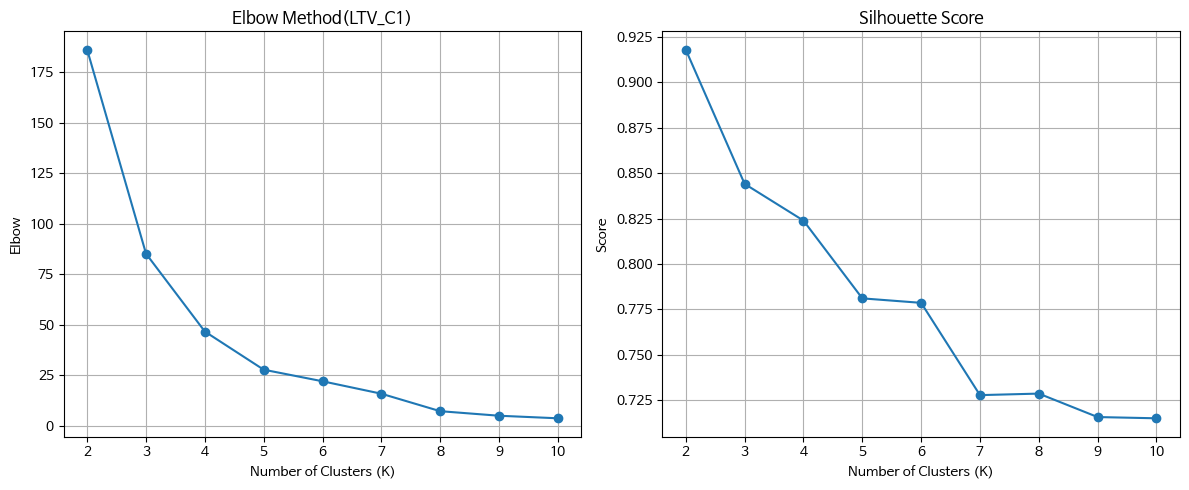

In [49]:
# 유저별 누적 유료 과금 재화(LTV_C1) 계산(매출 기여 가능 유저 식별 목적)
ltv_money = (user_money_daily.groupby('USER_ID')['CURRENCY1_USE_SUM'].sum().reset_index())
ltv_money.rename(columns = {'CURRENCY1_USE_SUM' : 'LTV_C1'},inplace=True)

# 무과금/과금 유저 분리(LTV_C1 기준)
payers = ltv_money[ltv_money['LTV_C1'] >0]                                      # 과금
non_payers = ltv_money[ltv_money['LTV_C1'] ==0]                                 # 무과금
non_payers['PAYER_SEGMENT'] = 'NonPayer'                                        # 무과금 명시 - NonPayer

# 과금 유저 군집화(K-means) - LTV_C1 기준
X_money = payers[['LTV_C1']]                                                    # 군집 대상
scaler = StandardScaler()                                                       # k-means 특성(거리 기반) -> 스케일링 필수
X_money_scaled = scaler.fit_transform(X_money)

# 최적 군집 수 설정(엘보우, 실루엣 계수)
elbow_money = []                                                                # 엘보우 값 저장
silhouette_scores_money = {}                                                    # 실루엣 계수 저장

k_range = range(2,11)
random_state = 42

for i in k_range :
    kmeans = KMeans(n_clusters=i, random_state=random_state, n_init = 'auto')
    labels = kmeans.fit_predict(X_money_scaled)
    elbow_money.append(kmeans.inertia_)                                         # 제곱합

    silhouette_scores_money[i] = silhouette_score(X_money_scaled, kmeans.labels_)           # 실루엣 계수 계산

# 엘보우/실루엣 계수 시각화
plt.figure(figsize=(12, 5))

# 엘보우 플롯
plt.subplot(1, 2, 1)
plt.plot(k_range, elbow_money, marker='o')
plt.title('Elbow Method(LTV_C1)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Elbow')
plt.grid(True)

# 실루엣 플롯
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores_money.values(), marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Score')
plt.grid(True)
plt.tight_layout()
plt.show();

In [50]:
# 과금 유저 세그먼트 확정(K-means(k=3)결과 기반 과금 수준 구간화)
k_money = 3
random_state = 42

kmeans = KMeans(n_clusters = k_money, random_state = random_state, n_init='auto')
payers['CLUSTER_MONEY'] = kmeans.fit_predict(X_money_scaled)                                                # 과금 수준 군집 할당

# 군집 중심값 기준 정렬(LTV_C1 평균 기준 -> 군집을 내림차순 정렬한 후 과금 수준 세그먼트 정의)
cluster_centers = payers.groupby('CLUSTER_MONEY')['LTV_C1'].mean().reset_index()
cluster_centers.rename(columns = {'LTV_C1': 'LTV_C1_Mean'},inplace=True)
cluster_centers = cluster_centers.sort_values(by='LTV_C1_Mean',ascending=False).reset_index(drop=True)      # 내림차순 정렬

# 과금 세그먼트 매핑(내림차순) - # index  0:whale / 1:Medium / 2:Small
segment_labels = ['Whale', 'Medium', 'Small']

cluster_mapping = {}
for i, cluster_id in enumerate(cluster_centers['CLUSTER_MONEY']):
    cluster_mapping[cluster_id] = segment_labels[i]

payers['PAYER_SEGMENT'] = payers['CLUSTER_MONEY'].map(cluster_mapping)
payers.drop(columns = ['CLUSTER_MONEY'], inplace=True)                                                      # 불필요 컬럼 제거

/tmp/ipython-input-3869937650.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  payers['CLUSTER_MONEY'] = kmeans.fit_predict(X_money_scaled)                                                # 과금 수준 군집 할당
/tmp/ipython-input-3869937650.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  payers['PAYER_SEGMENT'] = payers['CLUSTER_MONEY'].map(cluster_mapping)
/tmp/ipython-input-3869937650.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the do

In [51]:
# 세그먼트 통계적 타당성 검정(ANOVA)
anova_data_money = payers[['LTV_C1','PAYER_SEGMENT']]

model_money = ols('LTV_C1 ~ C(PAYER_SEGMENT)', data = anova_data_money).fit()
anova_table_money = sm.stats.anova_lm(model_money, typ=2)                       # typ=1(순서형) : 변수 순서 민감 / typ3(조건부 포함) : 복잡한 설계 / typ2 : 조건부 독립
anova_table_money

,sum_sq,df,F,PR(>F)
C(PAYER_SEGMENT),3.696054e+08,2.0,1237.377251,9.271185e-195
Residual,7.497386e+07,502.0,NaN,NaN


In [52]:
# 사후 검정(세그먼트 간 평균 LTV_C1 차이 검증) - 모든 세그먼트 쌍 간 평균 차이 비교
# reject가 모든 변수 True -> 유의

tukey_result_money = pairwise_tukeyhsd(endog=anova_data_money['LTV_C1'],        # 유저별 누적 과금 금액
                                 groups=anova_data_money['PAYER_SEGMENT'],      # 과금 세그먼트
                                 alpha=0.05)                                    # 유의수준

print(tukey_result_money)

    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
group1 group2  meandiff  p-adj   lower      upper    reject
-----------------------------------------------------------
Medium  Small -1832.5679   0.0 -1996.1994 -1668.9364   True
Medium  Whale  5619.9112   0.0  5183.9507  6055.8717   True
 Small  Whale  7452.4791   0.0  7044.0423   7860.916   True
-----------------------------------------------------------


In [53]:
# 최종 과금 세그먼트 데이터 통합(과금 유저 + 무과금 유저 세그먼트)

final_segmentation_money = pd.concat([
      payers[['USER_ID', 'LTV_C1', 'PAYER_SEGMENT']],
      non_payers[['USER_ID','LTV_C1','PAYER_SEGMENT']]],
      ignore_index=True, axis=0)                                                # 행 방향

# 유저별 일별 데이터에 과금 세그먼트 추가
user_money_daily_moneyClustered = user_money_daily.merge(
      final_segmentation_money[['USER_ID', 'PAYER_SEGMENT']],
      on='USER_ID',
      how='left'
)

# 최종 과금 세그먼트별 유저 수 확인
print('최종 과금 세그먼트별 유저 수''\n')
print(final_segmentation_money['PAYER_SEGMENT'].value_counts())

최종 과금 세그먼트별 유저 수

PAYER_SEGMENT
NonPayer    2397
Small        467
Medium        33
Whale          5
Name: count, dtype: int64


### 2. 성장 상태

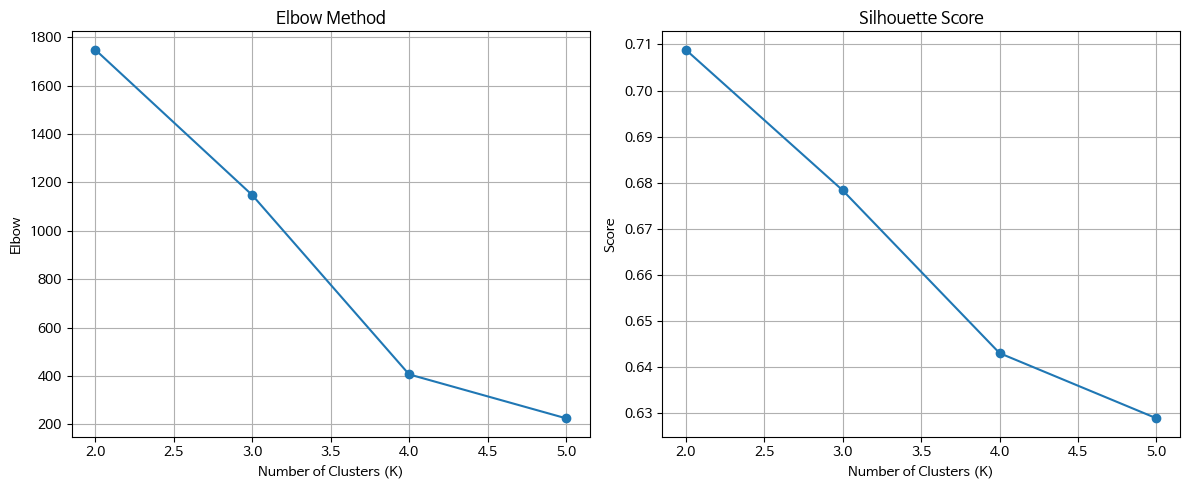

In [54]:
# 유저별 최대 전투력 및 레벨 추출 효율 계산
# ATTACK_POWER_LAST : 로그 기준 최근 전투력 -> 유저별 최대값을 최종 전투력으로 정의
user_ap = user_money_daily_moneyClustered.groupby('USER_ID')[['ATTACK_POWER_LAST','TOTAL_LEVEL_LAST']].max().reset_index()
user_ap.rename(columns={'ATTACK_POWER_LAST': 'FINAL_ATTACK_POWER', 'TOTAL_LEVEL_LAST': 'FINAL_TOTAL_LEVEL'},inplace=True)
user_ap = user_ap[user_ap['FINAL_TOTAL_LEVEL'] > 0]

# 성장 효율 지표 정의
user_ap['GROWTH_EFFICIENCY'] = user_ap['FINAL_ATTACK_POWER'] / user_ap['FINAL_TOTAL_LEVEL']


# K-means
X_ap = user_ap[['GROWTH_EFFICIENCY']]
scaler_ap = StandardScaler()
X_ap_scaled = scaler_ap.fit_transform(X_ap)

# 적정 군집 수 검토(엘보우 + 실루엣 계수)
elbow_ap = []
silhouette_scores_ap = {}

k_range = range(2,6)
random_state = 42

for i in k_range :
    kmeans = KMeans(n_clusters=i, random_state=random_state, n_init = 'auto')

    labels = kmeans.fit_predict(X_ap_scaled)
    elbow_ap.append(kmeans.inertia_)
    silhouette_scores_ap[i] = silhouette_score(X_ap_scaled, kmeans.labels_)

# 엘보우/실루엣 계수 시각화
plt.figure(figsize=(12, 5))

# 엘보우 플롯
plt.subplot(1, 2, 1)
plt.plot(k_range, elbow_ap, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Elbow')
plt.grid(True)

# 실루엣 플롯
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores_ap.values(), marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Score')
plt.grid(True)
plt.tight_layout()
plt.show();

In [55]:
# 전투력 기반 성장 단계 세그먼트 확정(K-means(k=3)결과 기반 전투력 수준 구간화)
k_ap = 3
random_state = 42

kmeans_ap = KMeans(n_clusters = k_ap, random_state = random_state, n_init='auto')
user_ap['CLUSTER_AP'] = kmeans_ap.fit_predict(X_ap_scaled)

# 군집 중심값 기준 정렬(전투력 평균 기준)
attack_centers = user_ap.groupby('CLUSTER_AP')['FINAL_ATTACK_POWER'].mean().reset_index()
attack_centers.rename(columns={'FINAL_ATTACK_POWER': 'AP_Center'},inplace=True)


# 전투력 수준 세그먼트 명칭 매핑(High > Mid > Low)
attack_centers = attack_centers.sort_values(by='AP_Center', ascending=False)\
                                            .reset_index(drop=True)

# 전투력 세그먼트 매핑 - index  0:HighTier / 1:MidTier / 2:LowTier
ap_tier_names = ['Hightier', 'Midtier', 'Lowtier']

ap_mapping = {}

for i, cluster_id in enumerate(attack_centers['CLUSTER_AP']):
    ap_mapping[cluster_id] = ap_tier_names[i]

user_ap['GROWTH_TIER'] = user_ap['CLUSTER_AP'].map(ap_mapping)

In [56]:
# 세그먼트 통계적 타당성 검정(ANOVA)
anova_data_ap = user_ap[['FINAL_ATTACK_POWER','GROWTH_TIER']]

anova_model_ap = ols('FINAL_ATTACK_POWER ~ C(GROWTH_TIER)', data = anova_data_ap).fit()
anova_table_ap = sm.stats.anova_lm(anova_model_ap, typ=2)
anova_table_ap

,sum_sq,df,F,PR(>F)
C(GROWTH_TIER),2.586028e+15,2.0,3893.221392,0.0
Residual,9.601567e+14,2891.0,NaN,NaN


In [57]:
# 사후 검정(전투력 세그먼트간 평균 전투력 차이)
tukey_result_ap = pairwise_tukeyhsd(endog=anova_data_ap['FINAL_ATTACK_POWER'],  # 비교 대상 : 유저별 최종 전투력                   # 비교 대상 : 유저별 누적 과금 금액
                                 groups=anova_data_ap['GROWTH_TIER'],           # 그룹 변수 : 전투력 세그먼트
                                 alpha=0.05)                                    # 유의수준

print(tukey_result_ap)

          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
 group1   group2    meandiff   p-adj     lower         upper     reject
-----------------------------------------------------------------------
Hightier Lowtier -8574925.7619   0.0 -8950777.9901 -8199073.5336   True
Hightier Midtier -6630517.4626   0.0 -7009606.6155 -6251428.3097   True
 Lowtier Midtier  1944408.2992   0.0  1880999.2171  2007817.3813   True
-----------------------------------------------------------------------


In [58]:
# 최종 전투력 세그먼트 데이터 통합
# user_money_daily_allsegmented
user_money_daily_allsegmented = user_money_daily_moneyClustered.merge(
    user_ap[['USER_ID', 'GROWTH_TIER']],
    on='USER_ID',
    how='left'
)

# 최종 전투력 세그먼트별 유저 수 확인
print('최종 전투력 티어 세그먼트별 유저 수''\n')
print(user_money_daily_allsegmented[['USER_ID', 'GROWTH_TIER']].drop_duplicates().groupby('GROWTH_TIER')['USER_ID'].count())

최종 전투력 티어 세그먼트별 유저 수

GROWTH_TIER
Hightier      13
Lowtier     2316
Midtier      565
Name: USER_ID, dtype: int64


## 핵심 유저 행동 추세 분석


In [59]:
# 핵심 타겟 유저 정의
prime_payer_segments = ['Whale','Medium']                                       # 매출 기반 핵심 유저
prime_growth_tier = 'Midtier'                                                   # 추가 성장 잠재력 유저

prime_target_data = user_money_daily_allsegmented[
    (user_money_daily_allsegmented['PAYER_SEGMENT'].isin(prime_payer_segments)) &
    (user_money_daily_allsegmented['GROWTH_TIER'] == prime_growth_tier)
]

# 핵심 타겟 고유 유저 수
prime_target_users_count = prime_target_data['USER_ID'].nunique()
print(f"이벤트 핵심 타겟 유저 수: {prime_target_users_count:,} 명 ")

이벤트 핵심 타겟 유저 수: 18 명 


In [60]:
# 핵심 타겟의 게임 재화(CURRENCY2) 일별 소모량
# 핵심 유저의 활동 수준과 이벤트 참여 패턴을 포괄적으로 보여주는 대표 지표
# 단순 매출 분석이 아닌, 행동 추세 및 이벤트 반응 확인을 위해 사용
daily_c2_use = prime_target_data.groupby('CREATED_DATE')['CURRENCY2_USE_SUM'].sum().reset_index()
daily_c2_use.rename(columns={'CURRENCY2_USE_SUM': 'TOTAL_C2_DECREASE'},inplace=True)
daily_c2_use.set_index('CREATED_DATE', inplace=True)

In [61]:
'''
rolling mean(이동평균) -> 데이터 흐름을 보기 위한 도구
비즈니스 / 서비스 / 게임 분석
일별 데이터의 노이즈를 제거하고, 유저 행동의 실제 흐름을 보기 위
강화 재화(CURRENCY2) 일별 소모량은 구조적으로 변동성이 크다
특정 날에 고과금 유저 1~2명이 대량 강화, 이벤트 전날 몰아서 강화, 개인 플레이 시간 편차
-> 이상치 자주 발생
-> 우연한 행동을 전략으로 오인할 위험이 크다

우리가 원하는건 시점 추천
-> 이동평균(7일)
, 게임은 요일 패턴이 강하다, 데이터 기간이 7일 내외이므로,
: 단기 변동성 제거, 전체 추세 강조,
EMA(지수이동평균) -> 최근 데이터에 가중치 부여 -> 최근 며칠 그런 데이터 없음


AR : 과거의 값 자체가 미래 값을 설명한다 -> 예측이 목적, 충분히 긴 시계열
어제 값이 오늘 값에 직접 영향

MA : 과거의 오차를 평균내서 현재를 설명, 단기 노이즈 제거

ARIMA : 추세 제거, 자기상관 충격 모두 고려, 미래 예측이 목적
데이터 길이 충분

우리는 예측이 목적이 아니다, 현재까지의 행동 패턴 요약을 통해 -> 인사이트
시계열 모델을 '모형 추정'이 목적이므로 충분한 데이터 길이가 필수
'''

# 7일 이동평균(Moving Average) 계산 - 단기 변동성 제거, 전체 추세 확인
daily_c2_use['MA_7_DAYS'] = daily_c2_use['TOTAL_C2_DECREASE'].rolling(window=7, min_periods=1).mean()


# 핵심 타깃 유저의 일별 총 CURRENCY2 사용량  -날짜별 사용량 합계
# rolling window -> window= 7 : 7일 단위 이동창 : 현재 날짜 기준으로 과거 6일 + 현재 총 7일 데이터의 평균을 계싼
# min_periods = 1 최소 1개 데이터가 있어도 계산


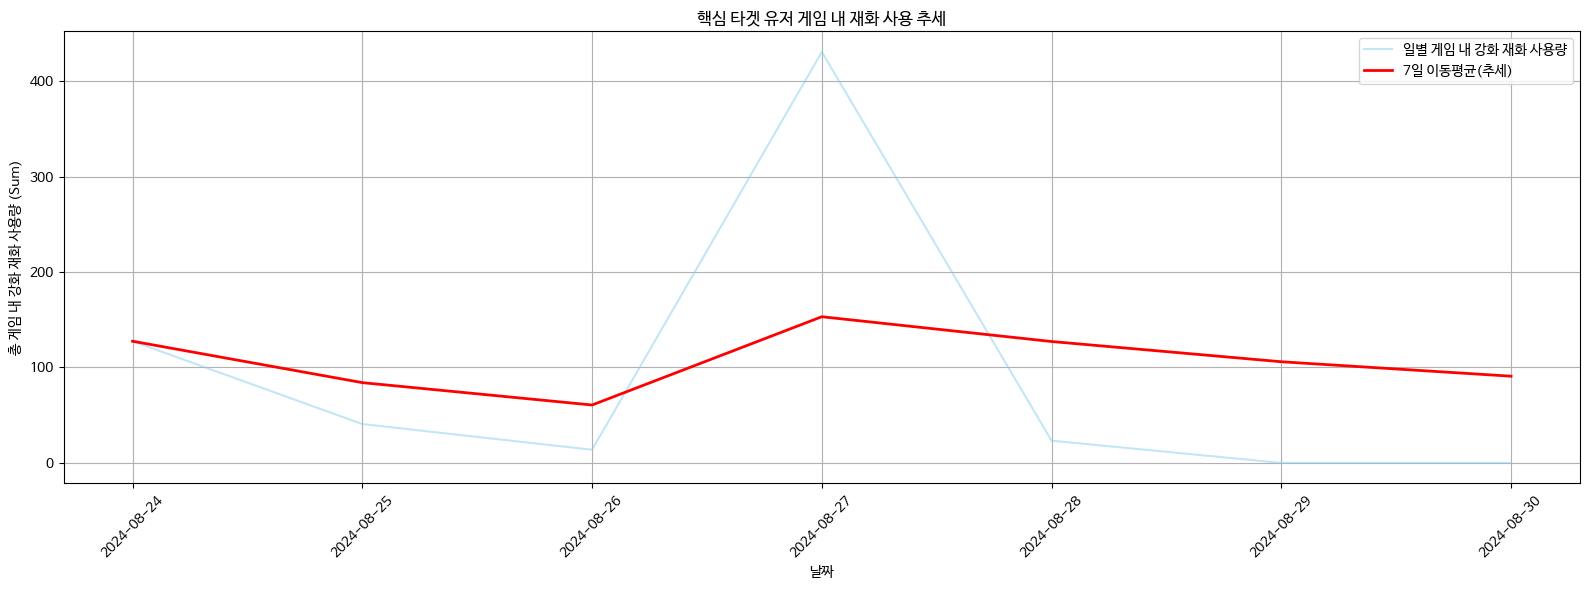

In [62]:
# 시각화
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(daily_c2_use.index, daily_c2_use['TOTAL_C2_DECREASE'],
        color='skyblue', alpha=0.5, label='일별 게임 내 강화 재화 사용량')
ax.plot(daily_c2_use.index, daily_c2_use['MA_7_DAYS'],
        color='red', linewidth=2, label='7일 이동평균(추세)')

ax.set_title(f'핵심 타겟 유저 게임 내 재화 사용 추세')
ax.set_xlabel('날짜')
ax.set_ylabel('총 게임 내 강화 재화 사용량 (Sum)')
ax.grid(True)
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()


In [63]:
# 일주일 주기 분석 - 핵심 타겟 유저의 게임 내 재화 사용량을 요일별 평균으로 분석해 주간 패턴 확인

# 요일 정보 추출
daily_c2_use['요일'] = daily_c2_use.index.day_name()                            # 인덱스 CREATED_DATE 에서 요일 정보 추출

# 요일별 평균 사용량 계산
weekday_mean = daily_c2_use.groupby('요일')['TOTAL_C2_DECREASE'].mean()

# 요일 순서 재정렬
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_mean = weekday_mean.reindex(order)

print("요일별 평균 CURRENCY2 소모량\n")
print(weekday_mean)

요일별 평균 CURRENCY2 소모량

요일
Monday        13.800000
Tuesday      430.685714
Wednesday     23.285714
Thursday       0.000000
Friday         0.000000
Saturday     127.500000
Sunday        40.714286
Name: TOTAL_C2_DECREASE, dtype: float64


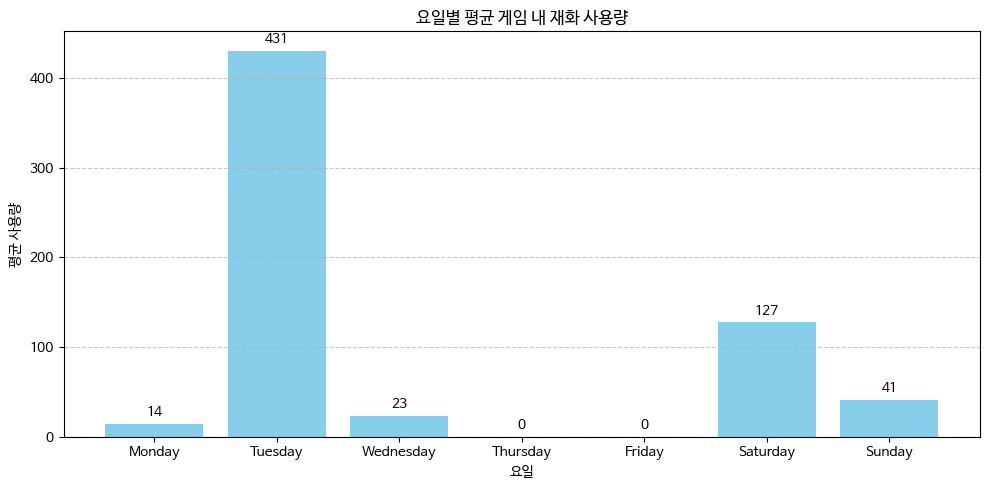

In [64]:
# 요일별 평균 게임 내 재화 사용량 시각화
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(weekday_mean.index, weekday_mean.values, color='skyblue')
ax.set_title('요일별 평균 게임 내 재화 사용량')
ax.set_xlabel('요일')
ax.set_ylabel('평균 사용량')
ax.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(weekday_mean.values):
    ax.text(i, v + max(weekday_mean.values)*0.01, f'{v:.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()
